# CanSat Data Analysis — GRASP & VAMOS Mission

**How to run:** `Kernel → Restart & Run All`.
**Dependencies:** `numpy pandas matplotlib scipy openpyxl` (all standard; install with `pip install openpyxl` if needed).

---

## Processing steps overview
1. **Data loading & cleaning** — GRASP (T, P, altitude, PM₂.₅, PM₁₀), VAMOS-science (CO₂, T, P), VAMOS-wind (speed, direction, acceleration), OBAMA external reference (T, P, RH, ρ)
2. **Exploratory visualisation** — time-series overview of every sensor channel
3. **Signal processing** — uniform resampling → Butterworth low-pass filter → Hanning-windowed FFT → Welch PSD → STFT spectrogram
4. **Scientific analysis** — temperature lapse rate vs ISA, PM₂.₅/PM₁₀ vertical profile, CO₂ vs atmospheric baseline, wind statistics
5. **External comparison** — ISA standard atmosphere, OBAMA CanSat dataset, WHO 2021 air-quality guidelines
6. **Error analysis** — GRASP sensor-init anomaly (row 0), CO₂ warm-up, tumbling-flag issue, GPS vs barometric altitude
7. **Discussion, limitations and conclusions**


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import butter, filtfilt, spectrogram, welch
from scipy.fft import fft, fftfreq
from scipy.interpolate import interp1d
from pathlib import Path

from utils import FIG_DIR, plot_uwyo_skewt, save_figure

DATA = Path('CanSat data utili')
UWYO_CSV = Path('dati/uwyo_06610_2026-02-05_12Z.csv')
UWYO_CSV_URL = 'http://weather.uwyo.edu/wsgi/sounding?datetime=2026-02-05%2012:00:00&id=06610&type=TEXT:CSV&src=BUFR'
UWYO_SKEWT_URL = 'http://weather.uwyo.edu/wsgi/sounding?datetime=2026-02-05%2012:00:00&id=06610&type=PNG:SKEWT&src=BUFR'
plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 10,
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
})

# ── ISA standard-atmosphere functions (ICAO, troposphere layer) ──────────────
P0, T0_K, L, g, Rd = 101325., 288.15, 6.5e-3, 9.80665, 287.058

def isa_alt(P):
    """Barometric altitude (m ASL) from absolute pressure (Pa)."""
    return (T0_K / L) * (1.0 - (np.asarray(P) / P0) ** (Rd * L / g))

def isa_press(h):
    return P0 * (1.0 - L * np.asarray(h) / T0_K) ** (g / (Rd * L))

def isa_temp_C(h):
    return T0_K - L * np.asarray(h) - 273.15


## Research Question

> **How do temperature, pressure, particulate matter (PM₂.₅/PM₁₀), CO₂ and wind speed vary with altitude and time during the GRASP–VAMOS CanSat mission, and what do time-frequency methods reveal about sensor behaviour and lower-troposphere structure?**

**Scientific motivation.**
The ISA dry-adiabatic lapse rate (−6.5 K km⁻¹) describes an idealised troposphere; deviations indicate stability anomalies (inversions, convective mixing). Aerosol concentration (PM₂.₅, PM₁₀) typically peaks inside the planetary boundary layer (0–2 km AGL) due to anthropogenic sources and weaker vertical mixing above. CO₂ in urban environments exceeds the global background (~420 ppm) from traffic and heating. Combining sensor readings at different altitudes provides a vertical snapshot of the lower troposphere above the launch site (Dübendorf, CH, 448 m ASL).

Time-frequency analysis (Welch PSD, STFT spectrogram) is applied to pressure and wind-acceleration signals to detect periodic oscillations (parachute pendulum motion), characterise turbulence, and identify residual sensor noise.


## Analysis Strategy

```
Raw data  ──►  Load & clean  ──►  Uniform resample
                                        │
                    ┌───────────────────┼─────────────────────┐
                    │                   │                     │
             Butterworth LP       Hanning FFT         STFT / Welch PSD
             (0.3 / 0.5 Hz)       power spectrum      time–frequency map
                    │                   │                     │
             Denoised trend       Dominant freqs       Spectral evolution
                    └───────────────────┴─────────────────────┘
                                        │
                           Physical interpretation
                           + External comparison
                           (ISA, OBAMA, WHO)
```

**Method choices & justification**
| Method | Choice | Reason |
|---|---|---|
| Low-pass IIR | 4th-order Butterworth, `filtfilt` | Maximally flat passband (no ripple); zero-phase preserves temporal alignment |
| Cutoff | 0.5 Hz (pressure), 0.3 Hz (T) | Atmospheric signals vary on ≫ 2 s; faster fluctuations are sensor noise |
| FFT window | Hanning | Reduces spectral leakage; side-lobe suppression critical near strong DC component |
| PSD estimator | Welch (nperseg = 256, 50% overlap) | Trades frequency resolution for variance reduction; appropriate for quasi-stationary signals |
| Spectrogram | STFT (nperseg = 128, 75% overlap) | Reveals *non-stationary* frequency content (oscillations that appear/stop mid-flight) |
| Gap handling | GRASP row 0 removed | Sensor-init artefact (see Error Analysis); inclusion would bias all spectral estimates |


In [ ]:
def resample_uniform(t, y, fs_new):
    """Resample y(t) on a uniform time grid using linear interpolation."""
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    keep = np.isfinite(t) & np.isfinite(y)
    t, y = t[keep], y[keep]
    order = np.argsort(t)
    t, y = t[order], y[order]
    t_unique, idx = np.unique(t, return_index=True)
    y_unique = y[idx]
    tu = np.arange(t_unique[0], t_unique[-1], 1.0 / fs_new)
    yu = np.interp(tu, t_unique, y_unique)
    return tu, yu


def baro_altitude_agl(p_hpa, p0_hpa):
    """Barometric altitude above local ground [m] using local reference pressure."""
    p_hpa = np.asarray(p_hpa, dtype=float)
    return 44330.0 * (1.0 - (p_hpa / p0_hpa) ** (1.0 / 5.255))


def met_to_uv(direction_deg, speed_ms):
    """Convert meteorological wind direction/speed to Cartesian u, v [m/s]."""
    ang = np.deg2rad(np.asarray(direction_deg, dtype=float))
    spd = np.asarray(speed_ms, dtype=float)
    u = -spd * np.sin(ang)
    v = -spd * np.cos(ang)
    return u, v


def detect_vamos_drop(vamos_df):
    p = vamos_df['press_hPa'].to_numpy(dtype=float)
    t = vamos_df['t_s'].to_numpy(dtype=float)
    p0 = (np.median(p[:100]) + np.median(p[-500:])) / 2
    h_agl = baro_altitude_agl(p, p0)
    p_smooth = pd.Series(p).rolling(5, center=True, min_periods=1).median().to_numpy()
    dpdt = np.gradient(p_smooth) / np.gradient(t)

    idx = np.where(dpdt > 0.1)[0]
    if len(idx) == 0:
        apogee_idx = int(np.argmin(p))
        landing_idx = len(p) - 1
    else:
        gaps = np.where(np.diff(idx) > 15)[0]
        starts = np.concatenate([[idx[0]], idx[gaps + 1]])
        ends = np.concatenate([idx[gaps], [idx[-1]]])
        dps = np.array([p[e] - p[s] for s, e in zip(starts, ends)])
        ds, de = starts[np.argmax(dps)], ends[np.argmax(dps)]
        look_back = max(0, ds - 60)
        apogee_idx = look_back + int(np.argmin(p[look_back:ds + 1]))
        look_fwd = min(len(p), de + 120)
        post_ground = np.where(p[de:look_fwd] > p0 - 0.5)[0]
        landing_idx = de + (post_ground[0] if len(post_ground) else 0)

    drop_mask = (t >= t[apogee_idx]) & (t <= t[landing_idx])
    return {
        'p0_hPa': float(p0),
        'h_agl': h_agl,
        'apogee_idx': int(apogee_idx),
        'landing_idx': int(landing_idx),
        't_apogee_s': float(t[apogee_idx]),
        't_landing_s': float(t[landing_idx]),
        'h_peak_m': float(h_agl[apogee_idx]),
        'drop_duration_s': float(t[landing_idx] - t[apogee_idx]),
        'descent_rate_mps': float((h_agl[apogee_idx] - h_agl[landing_idx]) / max(t[landing_idx] - t[apogee_idx], 1.0)),
        'drop_mask': drop_mask,
    }


def load_grasp():
    df = pd.read_csv(DATA / 'science_GRASP.csv',
                     usecols=[0, 2, 3, 4, 5, 6],
                     names=['t_ms','temp_C','press_Pa','alt_m','pm25','pm10'],
                     header=0, skipfooter=8, engine='python')
    df = df.dropna().astype(float)
    df['t_s']   = df['t_ms'] / 1000
    df['t_rel'] = df['t_s'] - df['t_s'].iat[0]
    return df


def load_vamos_science():
    df = pd.read_csv(DATA / 'science_VAMOS.csv')
    df.columns = ['t_ms','co2_ppm','temp_C','press_hPa']
    df = (df[df['t_ms'] != 'timestamp_ms']
            .apply(pd.to_numeric, errors='coerce').dropna())
    df['t_s']   = df['t_ms'] / 1000
    df['t_rel'] = df['t_s'] - df['t_s'].iat[0]
    df['alt_baro'] = isa_alt(df['press_hPa'].values * 100)
    return df.reset_index(drop=True)


def load_vamos_wind():
    df = pd.read_csv(DATA / 'wind_VAMOS.csv')
    df.columns = ['t_ms','wind_acc','wind_dir','wind_spd',
                  'x_acc','y_acc','x_mps','y_mps','tumbling']
    df = (df[df['t_ms'] != 'timestamp_ms']
            .apply(pd.to_numeric, errors='coerce').dropna())
    df['t_s'] = df['t_ms'] / 1000
    dt = np.diff(df['t_s'].values)
    reset_idx = np.where(dt < 0)[0]
    if len(reset_idx):
        df = df.iloc[reset_idx[-1] + 1:].copy()
    df = df.reset_index(drop=True)
    df['t_s']   = df['t_ms'] / 1000
    df['t_rel'] = df['t_s'] - df['t_s'].iat[0]
    df['wind_acc_vec'] = np.hypot(df['x_acc'], df['y_acc'])
    df['wind_spd_vec'] = np.hypot(df['x_mps'], df['y_mps'])
    return df


def load_obama():
    df = pd.read_excel(DATA / 'OBAMA_data_decoded.xlsx', sheet_name='decoded')
    return df.apply(pd.to_numeric, errors='coerce')


def load_uwyo_sounding():
    src = UWYO_CSV if UWYO_CSV.exists() else UWYO_CSV_URL
    df = pd.read_csv(src)
    rename = {
        'geopotential height_m': 'height_m',
        'dew point temperature_C': 'dewpoint_C',
        'wind direction_degree': 'wind_dir_deg',
        'wind speed_m/s': 'wind_spd_ms',
    }
    return df.rename(columns=rename)


grasp = load_grasp()
vamos = load_vamos_science()
wind  = load_vamos_wind()
obama = load_obama()
uwyo  = load_uwyo_sounding()

# Row 0 is a sensor-init artefact (see Error Analysis); removed for main analysis
grasp_ok = grasp.iloc[1:].copy()
grasp_ok['alt_baro'] = isa_alt(grasp_ok['press_Pa'].values)

# VAMOS: exclude CO₂ warm-up (sensor reports 0 until thermal equilibrium)
vamos_co2 = vamos[vamos['co2_ppm'] > 0].copy()

# Extract VAMOS samples concurrent with the GRASP flight (same absolute timestamps)
T0_g, T1_g = grasp_ok['t_ms'].iat[0], grasp_ok['t_ms'].iat[-1]
vamos_conc = vamos[(vamos['t_ms'] >= T0_g) & (vamos['t_ms'] <= T1_g)].copy()

# Data-driven VAMOS drop identification from pressure evolution
vamos_drop = detect_vamos_drop(vamos)
vamos['alt_agl'] = vamos_drop['h_agl']
wind['phase'] = 'other'
wind.loc[(wind['t_s'] >= vamos_drop['t_apogee_s']) & (wind['t_s'] <= vamos_drop['t_landing_s']), 'phase'] = 'drop'
wind.loc[wind['t_s'] > vamos_drop['t_landing_s'] + 30, 'phase'] = 'ground'

# Effective sampling rates from median inter-sample interval
FS_G = 1000.0 / np.median(np.diff(grasp_ok['t_ms'].values))
FS_V = 1000.0 / np.median(np.diff(vamos['t_ms'].values))
FS_W = 1000.0 / np.median(np.diff(wind['t_ms'].values))

print('─── Dataset summary ─────────────────────────────────────────────')
print(f'GRASP        : {len(grasp_ok):5d} rows | {grasp_ok["t_rel"].iat[-1]:.1f} s | fs ≈ {FS_G:.2f} Hz')
print(f'VAMOS-science: {len(vamos):5d} rows | {vamos["t_rel"].iat[-1]:.0f} s | fs ≈ {FS_V:.2f} Hz')
print(f'VAMOS-wind   : {len(wind):5d} rows | {wind["t_rel"].iat[-1]:.0f} s | fs ≈ {FS_W:.2f} Hz')
print(f'OBAMA (ext.) : {obama["Time_s"].count():5.0f} rows | up to {obama["Time_s"].max():.0f} s')
print(f'UWYO 06610   : {len(uwyo):5d} rows | sounding at 2026-02-05 12:00 UTC')
print(f'VAMOS rows concurrent with GRASP flight: {len(vamos_conc)}')
print(f'VAMOS drop identified from data: apogee {vamos_drop["t_apogee_s"]:.0f} s, landing {vamos_drop["t_landing_s"]:.0f} s, peak ≈ {vamos_drop["h_peak_m"]:.0f} m AGL')


─── Dataset summary ─────────────────────────────────────────────
GRASP        :  1715 rows | 176.4 s | fs ≈ 38.46 Hz
VAMOS-science:  9349 rows | 6079 s | fs ≈ 0.98 Hz
VAMOS-wind   :  9280 rows | 6074 s | fs ≈ 0.98 Hz
OBAMA (ext.) :    28 rows | up to 900 s
VAMOS rows concurrent with GRASP flight: 173


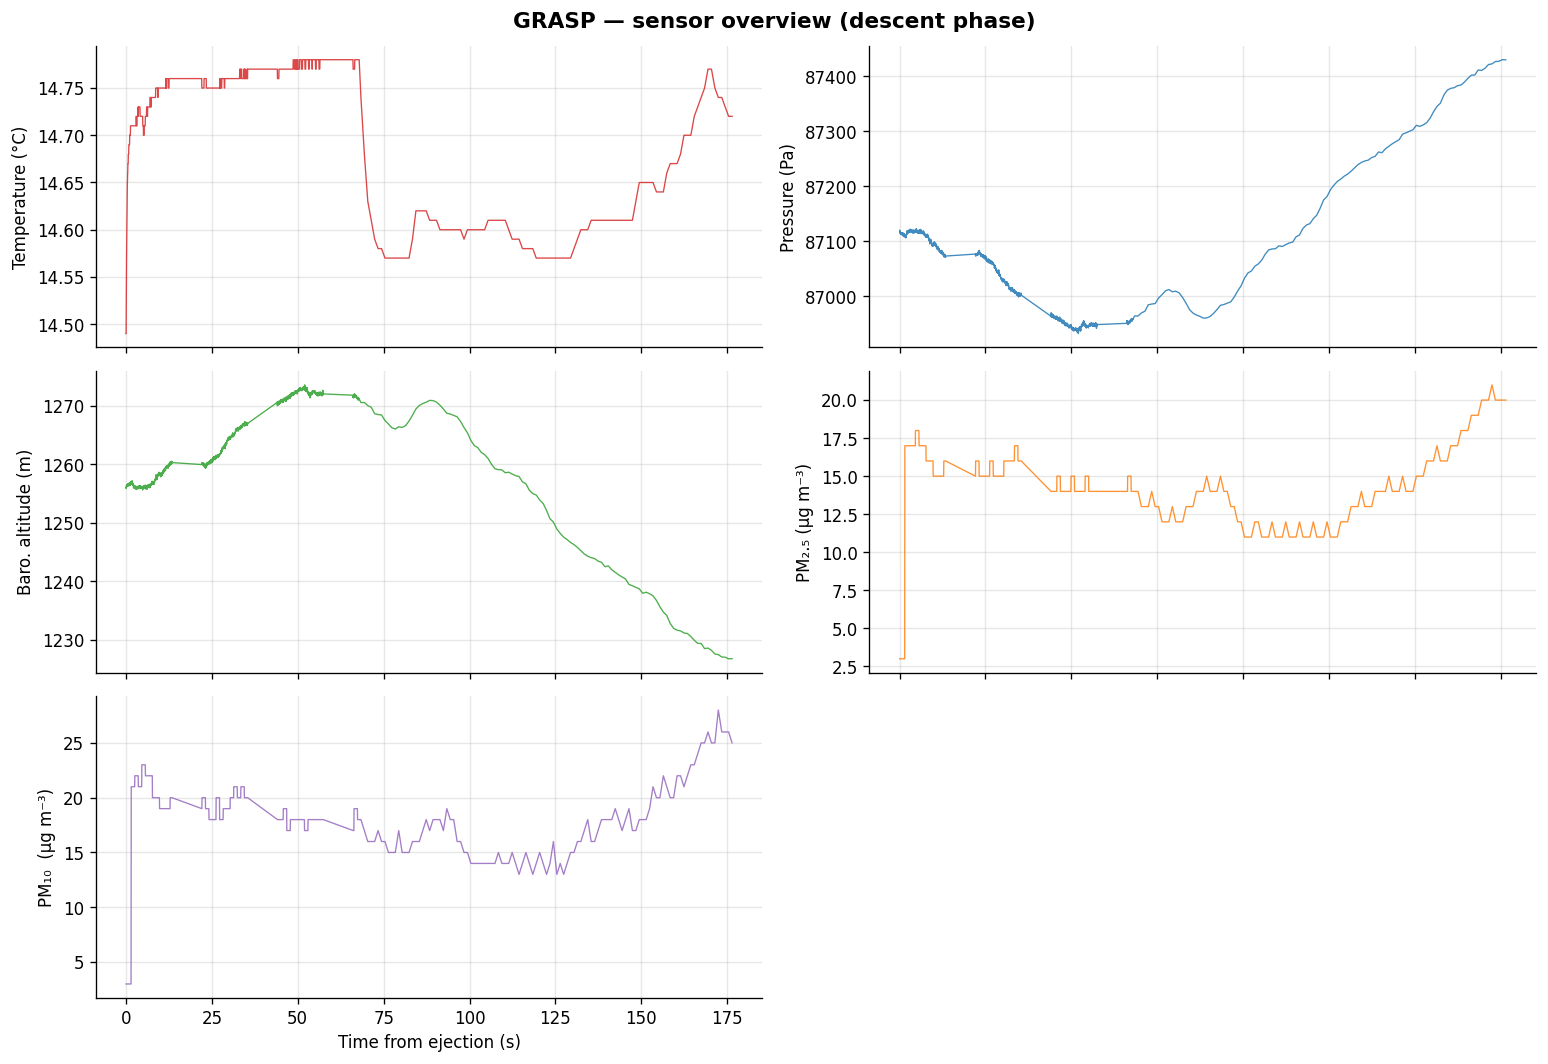

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(13, 9), sharex=True)
fig.suptitle('GRASP — sensor overview (descent phase)', fontsize=13, fontweight='bold')

t = grasp_ok['t_rel'].values

channels = [
    ('temp_C',   'Temperature (°C)',    'tab:red'),
    ('press_Pa', 'Pressure (Pa)',        'tab:blue'),
    ('alt_baro', 'Baro. altitude (m)',   'tab:green'),
    ('pm25',     'PM₂.₅ (µg m⁻³)',     'tab:orange'),
    ('pm10',     'PM₁₀  (µg m⁻³)',     'tab:purple'),
]
for ax, (col, lbl, clr) in zip(axes.flat, channels):
    ax.plot(t, grasp_ok[col].values, lw=0.8, color=clr, alpha=0.85)
    ax.set_ylabel(lbl)

for ax in axes[-1]:
    ax.set_xlabel('Time from ejection (s)')

axes.flat[-1].axis('off')          # hide 6th panel (only 5 channels)
axes.flat[-1].set_visible(False)
plt.tight_layout()
save_figure(fig, 'fig_grasp_overview.png')
plt.show()


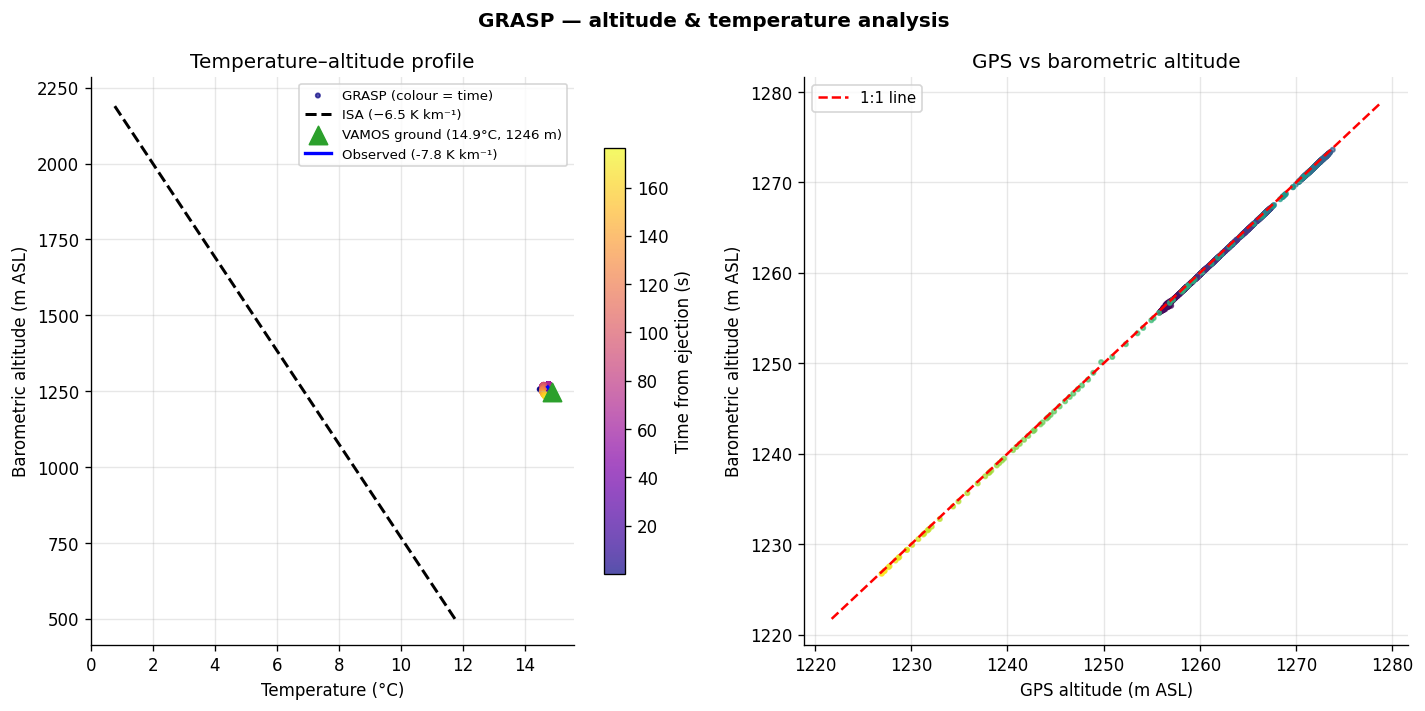

Observed lapse rate (VAMOS–GRASP pair): -7.8 K km⁻¹  |  ISA: 6.5 K km⁻¹
ISA temperature at 1264 m: 6.8°C
GRASP measured:                        14.7°C
Warm anomaly vs ISA:                  +8.0 K  (typical summer offset)


In [ ]:
h_model = np.linspace(500, 2200, 400)
T_model = isa_temp_C(h_model)

# Concurrent VAMOS ground reference (median during GRASP flight window)
h_ground = vamos_conc['alt_baro'].median() if len(vamos_conc) > 0 else isa_alt(vamos['press_hPa'].median()*100)
T_ground = vamos_conc['temp_C'].median()   if len(vamos_conc) > 0 else vamos['temp_C'].median()

# Observed lapse rate from the two-point VAMOS–GRASP pair
dT_obs = T_ground - grasp_ok['temp_C'].mean()
dh_obs = h_ground - grasp_ok['alt_baro'].mean()
lapse_obs = dT_obs / (dh_obs / 1000)     # K km⁻¹ (positive = cooler aloft)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('GRASP — altitude & temperature analysis', fontweight='bold')

# Left: T vs barometric altitude
sc = axes[0].scatter(grasp_ok['temp_C'], grasp_ok['alt_baro'],
                     c=grasp_ok['t_rel'], cmap='plasma', s=7, alpha=0.7,
                     label='GRASP (colour = time)')
plt.colorbar(sc, ax=axes[0], label='Time from ejection (s)', shrink=0.75)
axes[0].plot(T_model, h_model, 'k--', lw=1.8, label='ISA (−6.5 K km⁻¹)')
axes[0].scatter(T_ground, h_ground, s=120, color='tab:green', zorder=6,
                marker='^', label=f'VAMOS ground ({T_ground:.1f}°C, {h_ground:.0f} m)')
axes[0].plot([T_ground, grasp_ok['temp_C'].mean()],
             [h_ground,  grasp_ok['alt_baro'].mean()],
             'b-', lw=2, label=f'Observed ({lapse_obs:.1f} K km⁻¹)')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Barometric altitude (m ASL)')
axes[0].set_title('Temperature–altitude profile')
axes[0].legend(fontsize=8)

# Right: GPS vs barometric altitude (cross-validation)
axes[1].scatter(grasp_ok['alt_m'], grasp_ok['alt_baro'],
                c=grasp_ok['t_rel'], cmap='viridis', s=7, alpha=0.7)
lim = [min(grasp_ok['alt_m'].min(), grasp_ok['alt_baro'].min()) - 5,
       max(grasp_ok['alt_m'].max(), grasp_ok['alt_baro'].max()) + 5]
axes[1].plot(lim, lim, 'r--', lw=1.5, label='1:1 line')
axes[1].set_xlabel('GPS altitude (m ASL)')
axes[1].set_ylabel('Barometric altitude (m ASL)')
axes[1].set_title('GPS vs barometric altitude')
axes[1].legend(fontsize=9)

plt.tight_layout()
save_figure(fig, 'fig_altitude_temp.png')
plt.show()

T_isa_at_grasp = isa_temp_C(grasp_ok['alt_baro'].mean())
print(f'Observed lapse rate (VAMOS–GRASP pair): {lapse_obs:.1f} K km⁻¹  |  ISA: 6.5 K km⁻¹')
print(f'ISA temperature at {grasp_ok["alt_baro"].mean():.0f} m: {T_isa_at_grasp:.1f}°C')
print(f'GRASP measured:                        {grasp_ok["temp_C"].mean():.1f}°C')
print(f'Warm anomaly vs ISA:                  +{grasp_ok["temp_C"].mean()-T_isa_at_grasp:.1f} K  (typical summer offset)')


## Signal Processing

The GRASP pressure and temperature signals are processed through a full pipeline:

1. **Uniform resampling** — linear interpolation onto a regular grid (removes jitter in the 10 Hz stream)
2. **Butterworth low-pass filter** — isolates the physical atmospheric trend from high-frequency sensor noise
3. **Linear detrending** — removes the slow monotonic descent before spectral analysis so the spectrum reflects oscillatory content, not the DC drift
4. **Hanning-windowed FFT** — estimates the power spectrum with reduced spectral leakage
5. **Welch PSD** — variance-reduced spectral estimate by segment averaging
6. **STFT spectrogram** — reveals how spectral content evolves along the flight

The same spectral pipeline is applied to the VAMOS wind-acceleration signal.


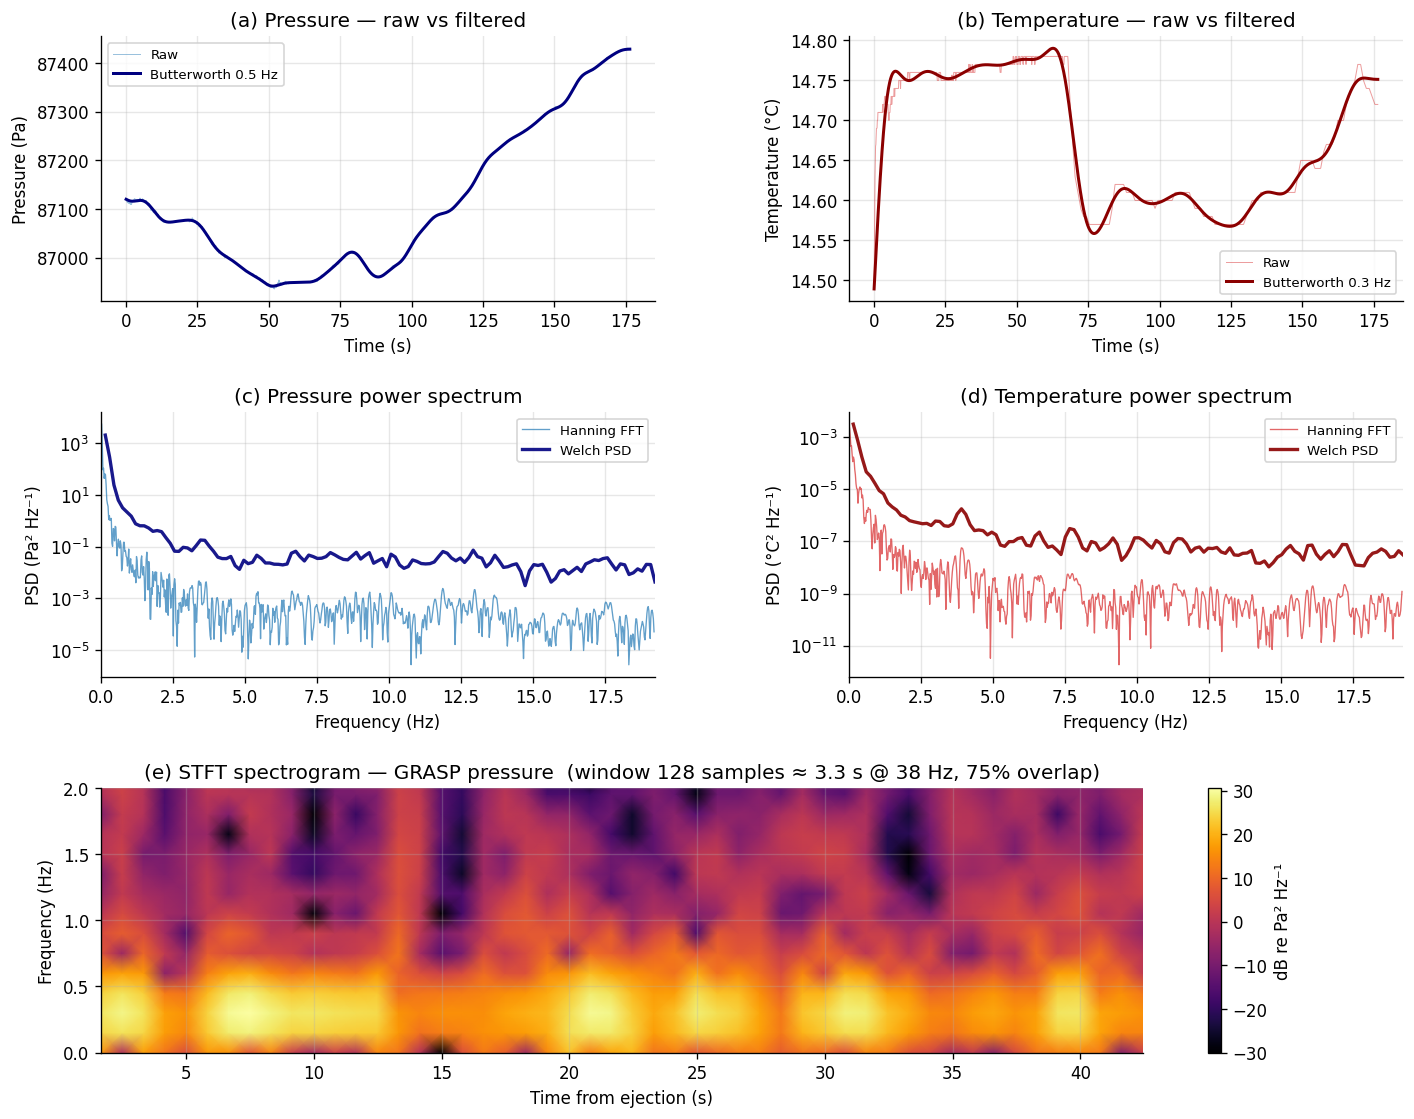

Nyquist freq (GRASP): 19.23 Hz
Welch Δf:      0.1502 Hz   Spectrogram Δf: 0.1502 Hz
Dominant pressure oscillation < 0.1 Hz → no significant parachute-pendulum resonance detected


In [ ]:
# ── 1. Uniform resampling ─────────────────────────────────────────────────────
t_in      = grasp_ok['t_rel'].values
press_raw = grasp_ok['press_Pa'].values
temp_raw  = grasp_ok['temp_C'].values

t_uni     = np.linspace(t_in[0], t_in[-1], len(grasp_ok))
press_uni = interp1d(t_in, press_raw, kind='linear')(t_uni)
temp_uni  = interp1d(t_in, temp_raw,  kind='linear')(t_uni)

# ── 2. Butterworth low-pass filter ────────────────────────────────────────────
def butter_lp(data, cutoff_hz, fs, order=4):
    b, a = butter(order, cutoff_hz / (0.5 * fs), btype='low')
    return filtfilt(b, a, data)        # zero-phase (no phase shift)

press_filt = butter_lp(press_uni, 0.5, FS_G)   # physical P changes ≫ 2 s
temp_filt  = butter_lp(temp_uni,  0.3, FS_G)   # T sensor responds even more slowly

# ── 3. Linear detrend before spectral analysis ────────────────────────────────
def detrend(x, t):
    return x - np.polyval(np.polyfit(t, x, 1), t)

press_detr = detrend(press_uni, t_uni)
temp_detr  = detrend(temp_uni,  t_uni)

# ── 4. Hanning-windowed FFT ───────────────────────────────────────────────────
N   = len(press_detr)
hw  = np.hanning(N)
nrm = np.sqrt(np.sum(hw ** 2))                  # normalise by window RMS

psd_press_fft = (np.abs(fft(press_detr * hw))[:N//2] / nrm) ** 2 * (2 / N)
psd_temp_fft  = (np.abs(fft(temp_detr  * hw))[:N//2] / nrm) ** 2 * (2 / N)
freqs_fft     = fftfreq(N, 1.0 / FS_G)[:N//2]

# ── 5. Welch PSD (nperseg = 256 → Δf ≈ 0.038 Hz, window ≈ 26 s) ─────────────
kw_welch = dict(fs=FS_G, window='hann', nperseg=256, noverlap=128)
f_wP, Pxx_P = welch(press_detr, **kw_welch)
f_wT, Pxx_T = welch(temp_detr,  **kw_welch)

# ── 6. STFT spectrogram (nperseg = 128 ≈ 13 s, 75% overlap → step ≈ 3 s) ─────
kw_spec = dict(fs=FS_G, window='hann', nperseg=128, noverlap=96, nfft=256)
f_spec, t_spec, Sxx_P = spectrogram(press_detr, **kw_spec)
_,       _,     Sxx_T = spectrogram(temp_detr,  **kw_spec)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 11))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.42, wspace=0.35)

# (a) Raw vs filtered pressure
ax = fig.add_subplot(gs[0, 0])
ax.plot(t_uni, press_uni,  lw=0.6, alpha=0.45, color='tab:blue',  label='Raw')
ax.plot(t_uni, press_filt, lw=1.8, color='navy',                   label='Butterworth 0.5 Hz')
ax.set_ylabel('Pressure (Pa)'); ax.set_xlabel('Time (s)')
ax.set_title('(a) Pressure — raw vs filtered'); ax.legend(fontsize=8)

# (b) Raw vs filtered temperature
ax = fig.add_subplot(gs[0, 1])
ax.plot(t_uni, temp_uni,  lw=0.6, alpha=0.45, color='tab:red',    label='Raw')
ax.plot(t_uni, temp_filt, lw=1.8, color='darkred',                 label='Butterworth 0.3 Hz')
ax.set_ylabel('Temperature (°C)'); ax.set_xlabel('Time (s)')
ax.set_title('(b) Temperature — raw vs filtered'); ax.legend(fontsize=8)

# (c) Power spectrum — pressure
ax = fig.add_subplot(gs[1, 0])
ax.semilogy(freqs_fft[1:], psd_press_fft[1:], lw=0.8,
            color='tab:blue', alpha=0.7, label='Hanning FFT')
ax.semilogy(f_wP[1:], Pxx_P[1:], lw=2.0, color='navy',
            alpha=0.9, label='Welch PSD')
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('PSD (Pa² Hz⁻¹)')
ax.set_title('(c) Pressure power spectrum'); ax.set_xlim(0, FS_G/2)
ax.legend(fontsize=8)

# (d) Power spectrum — temperature
ax = fig.add_subplot(gs[1, 1])
ax.semilogy(freqs_fft[1:], psd_temp_fft[1:], lw=0.8,
            color='tab:red', alpha=0.7, label='Hanning FFT')
ax.semilogy(f_wT[1:], Pxx_T[1:], lw=2.0, color='darkred',
            alpha=0.9, label='Welch PSD')
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('PSD (°C² Hz⁻¹)')
ax.set_title('(d) Temperature power spectrum'); ax.set_xlim(0, FS_G/2)
ax.legend(fontsize=8)

# (e) STFT spectrogram of pressure
ax = fig.add_subplot(gs[2, :])
pcm = ax.pcolormesh(t_spec, f_spec,
                    10 * np.log10(Sxx_P + 1e-12),
                    cmap='inferno', shading='gouraud', vmin=-30)
fig.colorbar(pcm, ax=ax, label='dB re Pa² Hz⁻¹')
ax.set_xlabel('Time from ejection (s)'); ax.set_ylabel('Frequency (Hz)')
ax.set_title('(e) STFT spectrogram — GRASP pressure  (window 128 samples ≈ 3.3 s @ 38 Hz, 75% overlap)')
ax.set_ylim(0, min(2.0, FS_G/2))

save_figure(fig, 'fig_signal_processing.png')
plt.show()
print(f'Nyquist freq (GRASP): {FS_G/2:.2f} Hz')
print(f'Welch Δf:      {f_wP[1]:.4f} Hz   Spectrogram Δf: {f_spec[1]:.4f} Hz')
print(f'Dominant pressure oscillation < 0.1 Hz → no significant parachute-pendulum resonance detected')


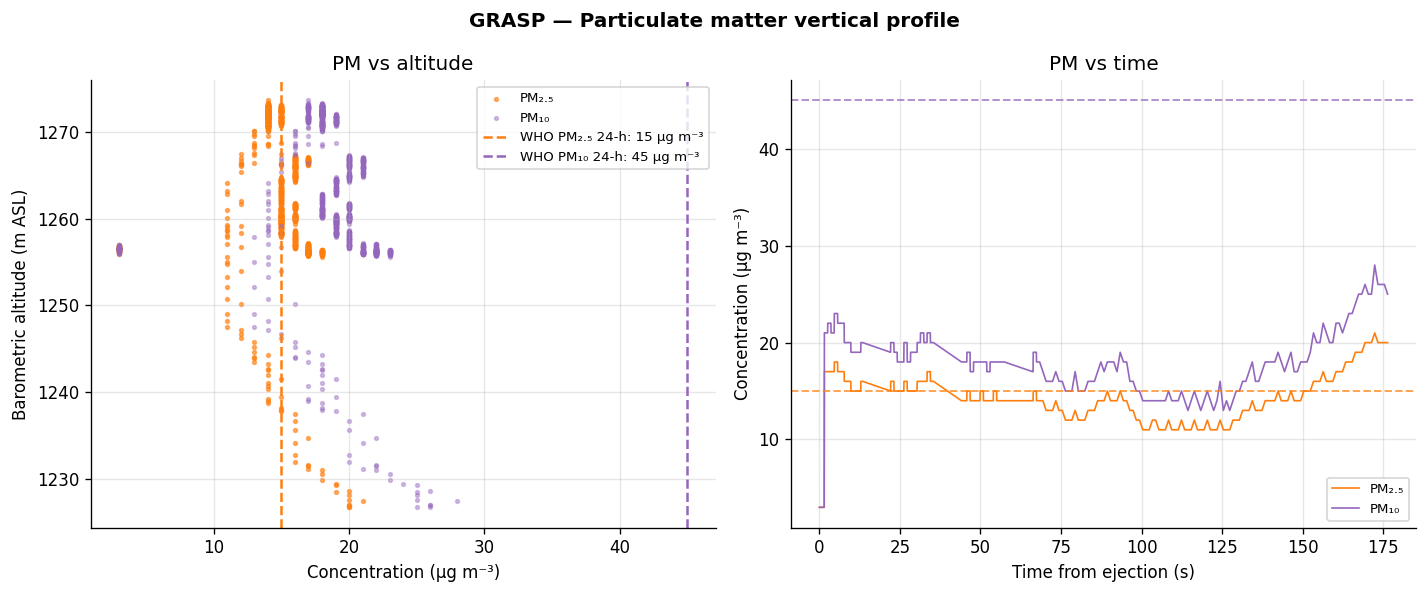

PM₂.₅: mean=14.8  max=21 µg m⁻³  (37% above WHO 24-h limit)
PM₁₀:  mean=18.6  max=28 µg m⁻³  (0% above WHO 24-h limit)


In [ ]:
WHO_PM25_24h = 15   # µg m⁻³  (WHO 2021 air-quality guideline, 24-h mean)
WHO_PM10_24h = 45

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('GRASP — Particulate matter vertical profile', fontweight='bold')

ax = axes[0]
ax.scatter(grasp_ok['pm25'], grasp_ok['alt_baro'], s=5, color='tab:orange',
           alpha=0.6, label='PM₂.₅')
ax.scatter(grasp_ok['pm10'], grasp_ok['alt_baro'], s=5, color='tab:purple',
           alpha=0.4, label='PM₁₀')
ax.axvline(WHO_PM25_24h, color='tab:orange', ls='--', lw=1.5,
           label=f'WHO PM₂.₅ 24-h: {WHO_PM25_24h} µg m⁻³')
ax.axvline(WHO_PM10_24h, color='tab:purple', ls='--', lw=1.5,
           label=f'WHO PM₁₀ 24-h: {WHO_PM10_24h} µg m⁻³')
ax.set_xlabel('Concentration (µg m⁻³)')
ax.set_ylabel('Barometric altitude (m ASL)')
ax.set_title('PM vs altitude'); ax.legend(fontsize=8)

ax = axes[1]
ax.plot(grasp_ok['t_rel'], grasp_ok['pm25'], color='tab:orange', lw=1.0, label='PM₂.₅')
ax.plot(grasp_ok['t_rel'], grasp_ok['pm10'], color='tab:purple', lw=1.0, label='PM₁₀')
ax.axhline(WHO_PM25_24h, color='tab:orange', ls='--', lw=1.2, alpha=0.7)
ax.axhline(WHO_PM10_24h, color='tab:purple', ls='--', lw=1.2, alpha=0.7)
ax.set_xlabel('Time from ejection (s)')
ax.set_ylabel('Concentration (µg m⁻³)')
ax.set_title('PM vs time'); ax.legend(fontsize=8)

plt.tight_layout()
save_figure(fig, 'fig_pm_analysis.png')
plt.show()
print(f'PM₂.₅: mean={grasp_ok["pm25"].mean():.1f}  max={grasp_ok["pm25"].max():.0f} µg m⁻³  '
      f'({(grasp_ok["pm25"]>WHO_PM25_24h).mean()*100:.0f}% above WHO 24-h limit)')
print(f'PM₁₀:  mean={grasp_ok["pm10"].mean():.1f}  max={grasp_ok["pm10"].max():.0f} µg m⁻³  '
      f'({(grasp_ok["pm10"]>WHO_PM10_24h).mean()*100:.0f}% above WHO 24-h limit)')


## VAMOS — Science Data (CO₂, Temperature, Pressure)

VAMOS recorded continuously for ~100 min, covering the entire mission including the period concurrent with the GRASP descent. The CO₂ sensor requires a warm-up period (~7 min) before readings are valid; those zero values are excluded from analysis.


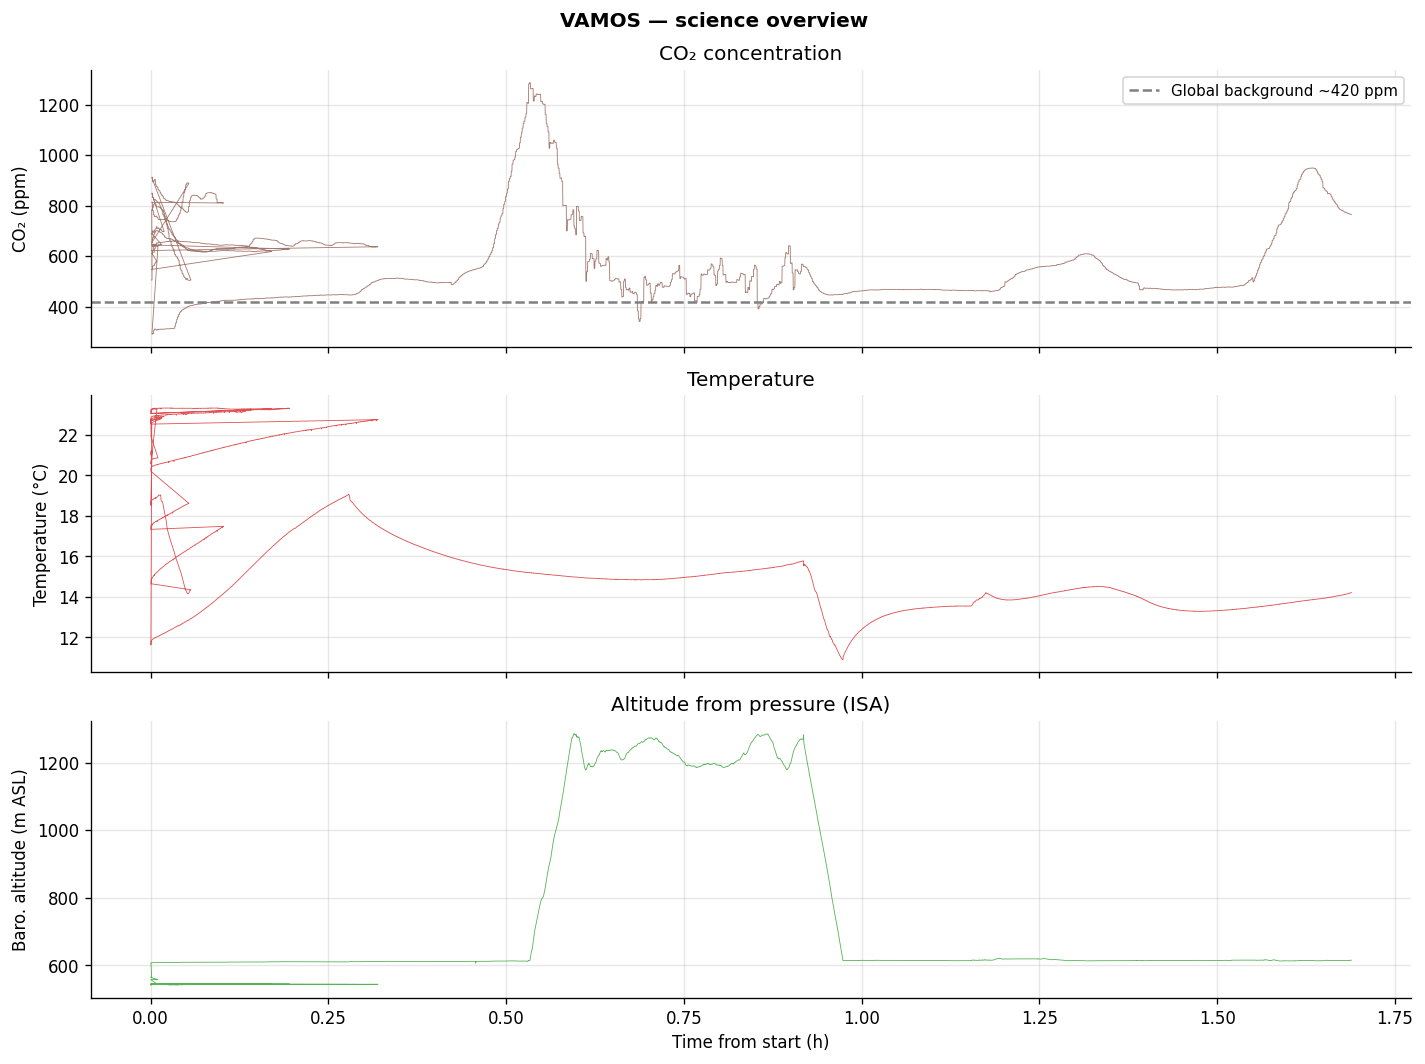

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.suptitle('VAMOS — science overview', fontweight='bold')

t_h = vamos['t_rel'].values / 3600

axes[0].plot(vamos_co2['t_rel']/3600, vamos_co2['co2_ppm'],
             lw=0.5, color='tab:brown', alpha=0.8)
axes[0].axhline(420, ls='--', color='gray', lw=1.5, label='Global background ~420 ppm')
axes[0].set_ylabel('CO₂ (ppm)'); axes[0].set_title('CO₂ concentration')
axes[0].legend(fontsize=9)

axes[1].plot(t_h, vamos['temp_C'], lw=0.5, color='tab:red', alpha=0.8)
axes[1].set_ylabel('Temperature (°C)'); axes[1].set_title('Temperature')

axes[2].plot(t_h, vamos['alt_baro'], lw=0.5, color='tab:green', alpha=0.8)
axes[2].set_ylabel('Baro. altitude (m ASL)')
axes[2].set_xlabel('Time from start (h)')
axes[2].set_title('Altitude from pressure (ISA)')

plt.tight_layout()
save_figure(fig, 'fig_vamos_science.png')
plt.show()


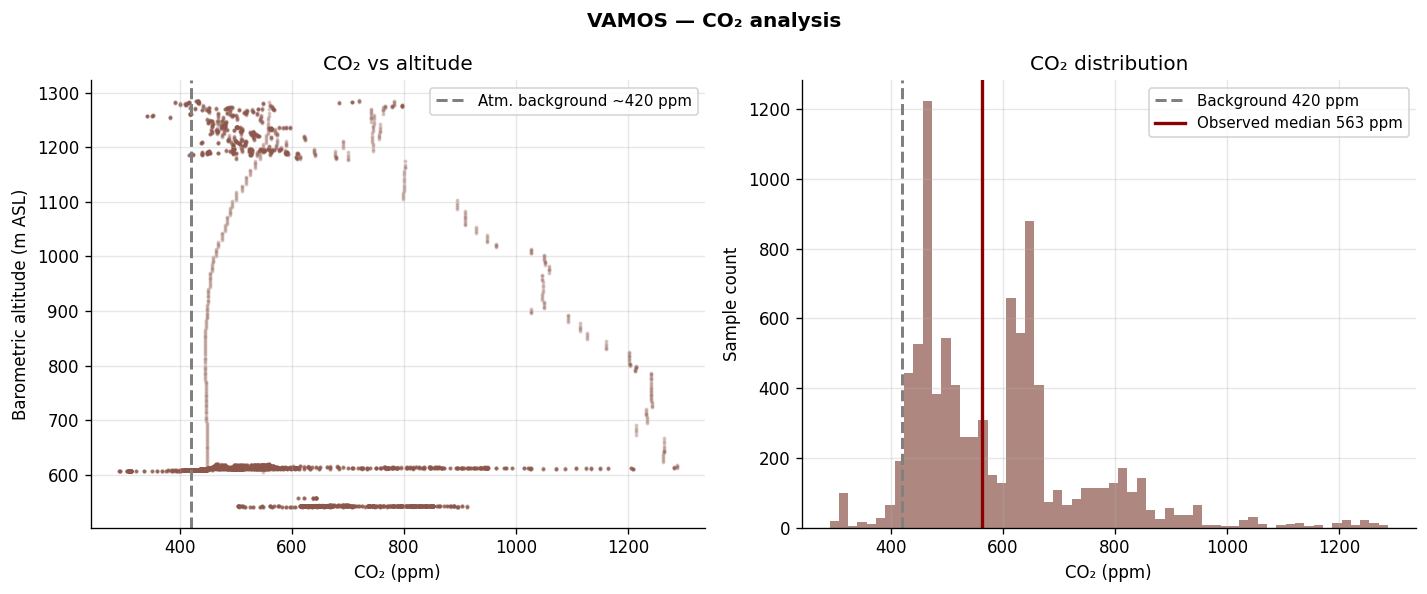

Median CO₂: 563 ppm  |  Excess above background: +143 ppm (34%)
Max CO₂: 1287 ppm — likely local plume or measurement artefact


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('VAMOS — CO₂ analysis', fontweight='bold')

# CO₂ vs altitude
ax = axes[0]
ax.scatter(vamos_co2['co2_ppm'], vamos_co2['alt_baro'],
           s=2, alpha=0.25, color='tab:brown')
ax.axvline(420, ls='--', color='gray', lw=1.8, label='Atm. background ~420 ppm')
ax.set_xlabel('CO₂ (ppm)'); ax.set_ylabel('Barometric altitude (m ASL)')
ax.set_title('CO₂ vs altitude'); ax.legend(fontsize=9)

# Distribution
ax = axes[1]
ax.hist(vamos_co2['co2_ppm'], bins=60, color='tab:brown', alpha=0.7, edgecolor='none')
ax.axvline(420, ls='--', color='gray',    lw=1.8, label='Background 420 ppm')
med_co2 = vamos_co2['co2_ppm'].median()
ax.axvline(med_co2, ls='-', color='darkred', lw=2,
           label=f'Observed median {med_co2:.0f} ppm')
ax.set_xlabel('CO₂ (ppm)'); ax.set_ylabel('Sample count')
ax.set_title('CO₂ distribution'); ax.legend(fontsize=9)

plt.tight_layout()
save_figure(fig, 'fig_co2_analysis.png')
plt.show()
excess = med_co2 - 420
print(f'Median CO₂: {med_co2:.0f} ppm  |  Excess above background: +{excess:.0f} ppm ({excess/420*100:.0f}%)')
print(f'Max CO₂: {vamos_co2["co2_ppm"].max():.0f} ppm — likely local plume or measurement artefact')


## VAMOS — Wind Data

The VAMOS anemometer records 2D wind speed, direction and X/Y components. A `tumbling` boolean flag (derived on-board from acceleration thresholds) is also stored. Spectral analysis of the wind-acceleration signal characterises the temporal distribution of turbulent gusts.


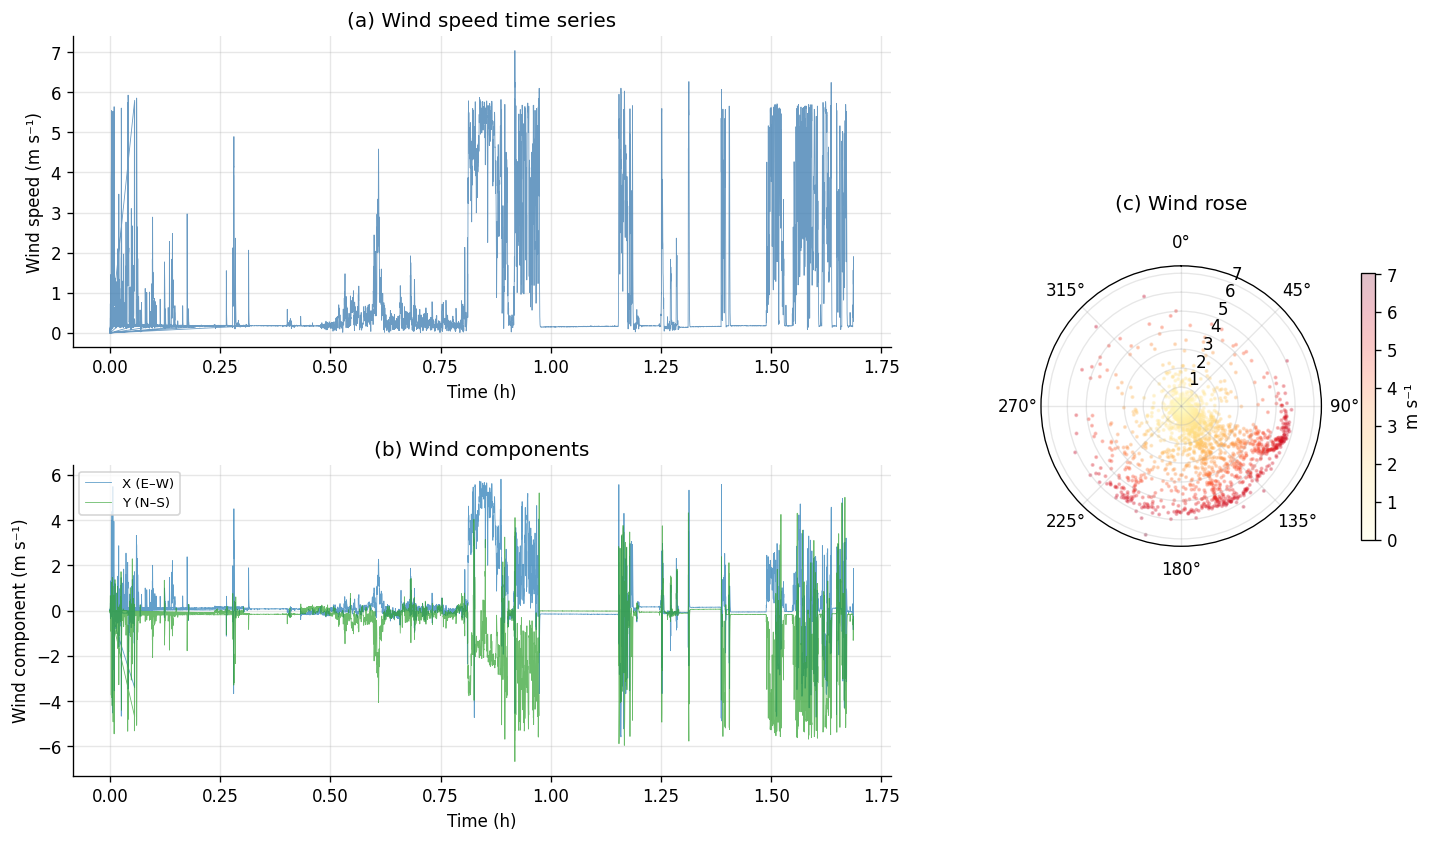

Mean wind speed: 0.71 m s⁻¹  |  Max: 7.04 m s⁻¹
Mean wind acc:   1.22 m s⁻²  |  Max: 12.18 m s⁻²


In [ ]:
fig = plt.figure(figsize=(14, 8))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.45)

drop_t0_h = (vamos_drop['t_apogee_s'] - wind['t_s'].iat[0]) / 3600
drop_t1_h = (vamos_drop['t_landing_s'] - wind['t_s'].iat[0]) / 3600

t_wh = wind['t_rel'].values / 3600

ax = fig.add_subplot(gs[0, :2])
ax.plot(t_wh, wind['wind_spd'], lw=0.5, color='steelblue', alpha=0.8)
ax.axvspan(drop_t0_h, drop_t1_h, color='tab:orange', alpha=0.18,
           label='Data-driven drop phase')
ax.set_ylabel('Wind speed (m s⁻¹)'); ax.set_xlabel('Time (h)')
ax.set_title('(a) Wind speed time series')
ax.legend(fontsize=8)

ax = fig.add_subplot(gs[1, :2])
ax.plot(t_wh, wind['x_mps'], lw=0.5, color='tab:blue',  alpha=0.7, label='X (E–W)')
ax.plot(t_wh, wind['y_mps'], lw=0.5, color='tab:green', alpha=0.7, label='Y (N–S)')
ax.axvspan(drop_t0_h, drop_t1_h, color='tab:orange', alpha=0.18)
ax.set_ylabel('Wind component (m s⁻¹)'); ax.set_xlabel('Time (h)')
ax.set_title('(b) Wind components with drop-phase highlight'); ax.legend(fontsize=8)

ax = fig.add_subplot(gs[:, 2], projection='polar')
theta = np.deg2rad(wind['wind_dir'].values)
r     = wind['wind_spd'].values
sc    = ax.scatter(theta, r, s=3, alpha=0.25, c=wind['t_rel']/60, cmap='YlOrRd')
ax.set_theta_zero_location('N'); ax.set_theta_direction(-1)
ax.set_title('(c) Wind rose (colour = mission minute)', pad=15)
plt.colorbar(sc, ax=ax, label='Minutes from wind start', pad=0.12, fraction=0.04)

save_figure(fig, 'fig_wind_overview.png')
plt.show()
print(f'Mean wind speed: {wind["wind_spd"].mean():.2f} m s⁻¹  |  Max: {wind["wind_spd"].max():.2f} m s⁻¹')
print(f'Mean vector wind speed: {wind["wind_spd_vec"].mean():.2f} m s⁻¹')
print(f'VAMOS drop duration from pressure: {vamos_drop["drop_duration_s"]:.0f} s  |  Mean descent rate: {vamos_drop["descent_rate_mps"]:.2f} m s⁻¹')


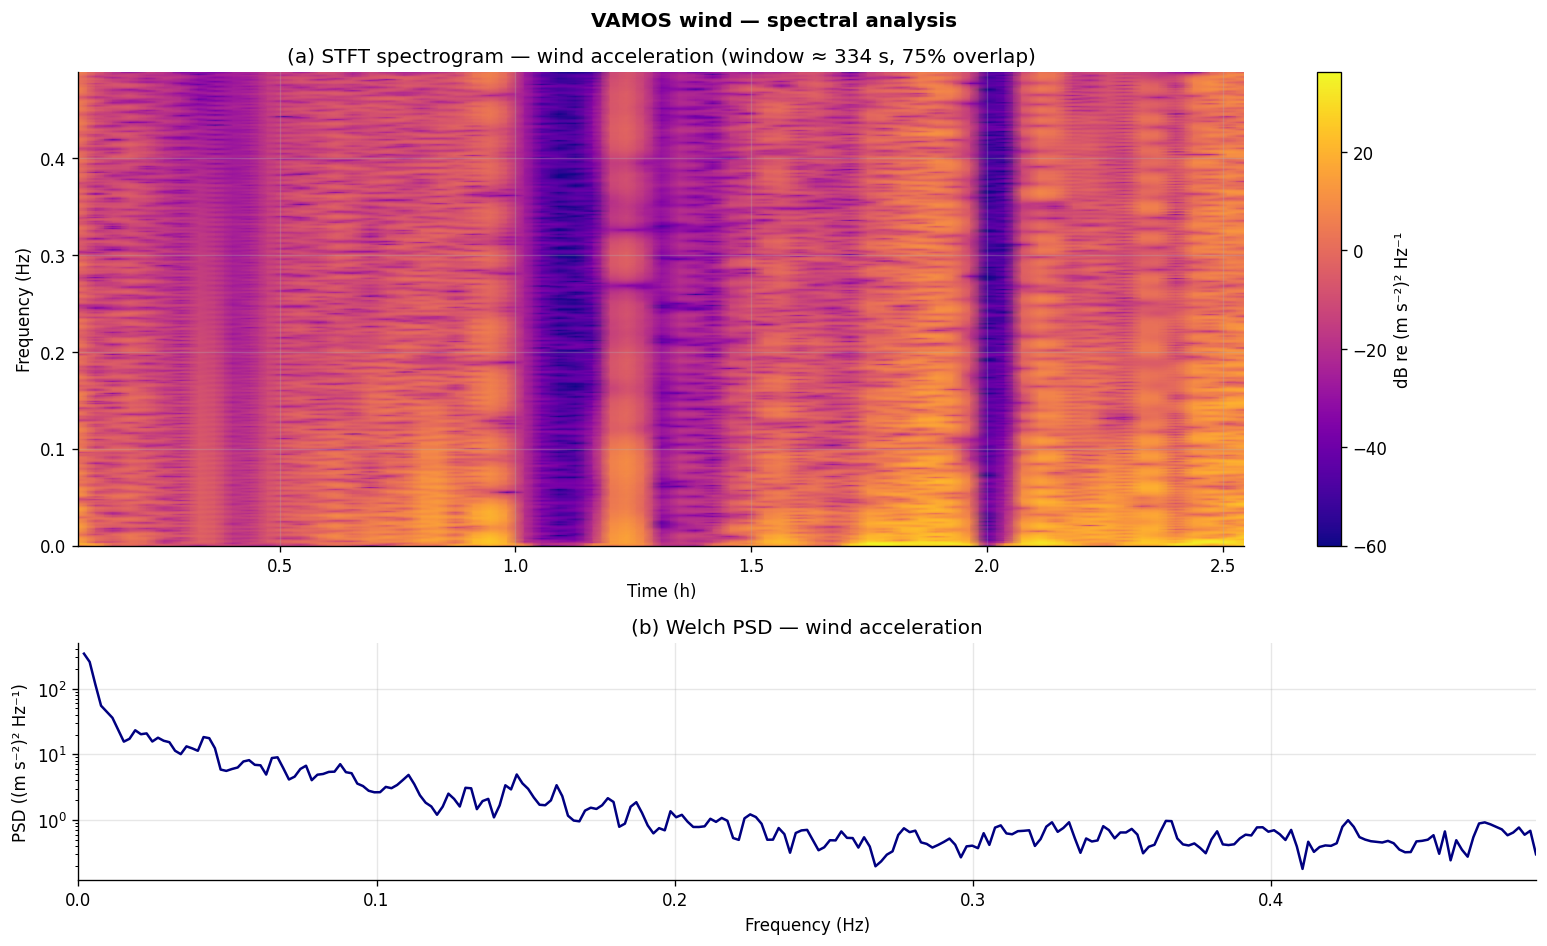

In [ ]:
def compute_welch_psd(t, y, fs, nperseg, noverlap=None):
    if noverlap is None:
        noverlap = nperseg // 2
    tu, yu = resample_uniform(t, y, fs)
    yu = yu - np.mean(yu)
    nperseg_actual = min(nperseg, len(yu))
    noverlap_actual = min(noverlap, max(nperseg_actual - 1, 0))
    f, P = welch(yu, fs=fs, window='hann', nperseg=nperseg_actual,
                 noverlap=noverlap_actual, detrend='linear', scaling='density')
    dof = 2 * (len(yu) / max(nperseg_actual, 1)) * 2.2
    return f, P, len(yu), dof


# ── Phase-aware VAMOS wind analysis merged from the dedicated spectral script ─
fs_psd = 1.0
nperseg_psd = 64
acc_sig = wind['wind_acc_vec'].values

in_plane_idx = np.where(vamos['press_hPa'].values < vamos_drop['p0_hPa'] - 30)[0]
if len(in_plane_idx):
    t_plane_start = vamos['t_s'].iloc[in_plane_idx[0]] + 60
    t_plane_end = vamos_drop['t_apogee_s'] - 30
else:
    t_plane_start = wind['t_s'].min()
    t_plane_end = vamos_drop['t_apogee_s']

phase_masks = {
    'aircraft / cruise': ((wind['t_s'] > t_plane_start) & (wind['t_s'] < t_plane_end), 'tab:blue'),
    'drop / parachute': ((wind['t_s'] >= vamos_drop['t_apogee_s']) & (wind['t_s'] <= vamos_drop['t_landing_s']), 'tab:red'),
    'ground / post-landing': (wind['t_s'] > vamos_drop['t_landing_s'] + 30, '0.4'),
}

# Spectrogram on uniformly resampled vector acceleration
fs_spec = max(1.0, round(FS_W))
tu_w, wacc_u = resample_uniform(wind['t_s'].values, acc_sig, fs_spec)
wacc_u = wacc_u - np.mean(wacc_u)
nperseg_spec = int(min(256, max(64, len(wacc_u) // 8)))
noverlap_spec = int(nperseg_spec * 0.75)
f_wind, t_wind, Sww = spectrogram(wacc_u, fs=fs_spec, window='hann',
                                  nperseg=nperseg_spec, noverlap=noverlap_spec,
                                  scaling='density')

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.34, wspace=0.28,
                        height_ratios=[1, 1.15])
fig.suptitle('VAMOS wind — phase-aware spectral analysis', fontweight='bold')

# (a) Pressure with data-driven drop detection
ax = fig.add_subplot(gs[0, 0])
ax.plot(vamos['t_rel']/60, vamos['press_hPa'], lw=0.8, color='tab:blue')
ax.axhline(vamos_drop['p0_hPa'], ls=':', color='0.4', lw=1.2,
           label=f'p₀ ≈ {vamos_drop["p0_hPa"]:.1f} hPa')
ax.axvspan((vamos_drop['t_apogee_s'] - vamos['t_s'].iat[0]) / 60,
           (vamos_drop['t_landing_s'] - vamos['t_s'].iat[0]) / 60,
           color='tab:orange', alpha=0.2, label='drop phase')
ax.set_xlabel('Time from start (min)')
ax.set_ylabel('Pressure (hPa)')
ax.set_title('(a) Pressure-based drop identification')
ax.legend(fontsize=8)

# (b) Spectrogram of wind acceleration magnitude
ax = fig.add_subplot(gs[1, 0])
pcm = ax.pcolormesh((t_wind + tu_w[0] - wind['t_s'].iat[0]) / 60, f_wind,
                    10 * np.log10(Sww + 1e-12), cmap='viridis', shading='gouraud')
ax.axvline((vamos_drop['t_apogee_s'] - wind['t_s'].iat[0]) / 60, color='r', ls='--', lw=1)
ax.axvline((vamos_drop['t_landing_s'] - wind['t_s'].iat[0]) / 60, color='g', ls='--', lw=1)
ax.set_xlabel('Time from wind start (min)')
ax.set_ylabel('Frequency (Hz)')
ax.set_ylim(0, fs_spec / 2)
ax.set_title(f'(b) STFT of |wind acceleration| (fs={fs_spec:.0f} Hz, nperseg={nperseg_spec})')
fig.colorbar(pcm, ax=ax, label='dB re (m s⁻²)² Hz⁻¹')

# (c) Welch PSD of vector acceleration by flight phase
ax = fig.add_subplot(gs[0, 1])
for name, (mask, color) in phase_masks.items():
    if mask.sum() < 32:
        continue
    f, P, Nu, dof = compute_welch_psd(wind.loc[mask, 't_s'], wind.loc[mask, 'wind_acc_vec'],
                                      fs=fs_psd, nperseg=nperseg_psd)
    ax.loglog(f[1:], P[1:], color=color, lw=1.5,
              label=f'{name} (N={Nu}, DoF≈{dof:.0f})')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD ((m s⁻²)² Hz⁻¹)')
ax.set_title('(c) Welch PSD — vector acceleration')
ax.legend(fontsize=8, loc='lower left')

# (d) Welch PSD of wind speed by flight phase
ax = fig.add_subplot(gs[1, 1])
for name, (mask, color) in phase_masks.items():
    if mask.sum() < 32:
        continue
    f, P, Nu, dof = compute_welch_psd(wind.loc[mask, 't_s'], wind.loc[mask, 'wind_spd'],
                                      fs=fs_psd, nperseg=nperseg_psd)
    ax.loglog(f[1:], P[1:], color=color, lw=1.5,
              label=f'{name} (N={Nu}, DoF≈{dof:.0f})')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD ((m s⁻¹)² Hz⁻¹)')
ax.set_title('(d) Welch PSD — wind speed')
ax.legend(fontsize=8, loc='lower left')

plt.tight_layout()
save_figure(fig, 'fig_wind_spectrogram.png')
plt.show()

print(f'Peak VAMOS altitude: {vamos_drop["h_peak_m"]:.0f} m AGL')
print(f'Drop duration: {vamos_drop["drop_duration_s"]:.0f} s  |  Mean descent rate: {vamos_drop["descent_rate_mps"]:.2f} m s⁻¹')
print('The phase-separated PSD is more informative than a single full-mission PSD because it isolates aircraft, parachute and ground regimes.')


## External Datasets & Comparison

Four external references are used:

1. **ISA standard atmosphere** (ICAO Doc 7488) — theoretical baseline for temperature and pressure vs altitude; allows quantification of deviations due to weather, season and location.
2. **OBAMA CanSat** — a second CanSat deployed in the same competition (Dübendorf site). Its dual-sensor suite measures temperature, static pressure, relative humidity and air density, providing an independent in-situ measurement of ground-level conditions concurrent with the GRASP descent.
3. **WHO 2021 Air Quality Guidelines** — 24-h mean limits for PM₂.₅ (15 µg m⁻³) and PM₁₀ (45 µg m⁻³) used to contextualise the measured aerosol concentrations.
4. **University of Wyoming radiosonde (station 06610, 2026-02-05 12:00 UTC)** — synoptic upper-air context used to inspect the thermodynamic profile and the vertical wind shear. The notebook uses the CSV listing saved locally in `dati/uwyo_06610_2026-02-05_12Z.csv` and keeps the original Skew-T URL for reference.


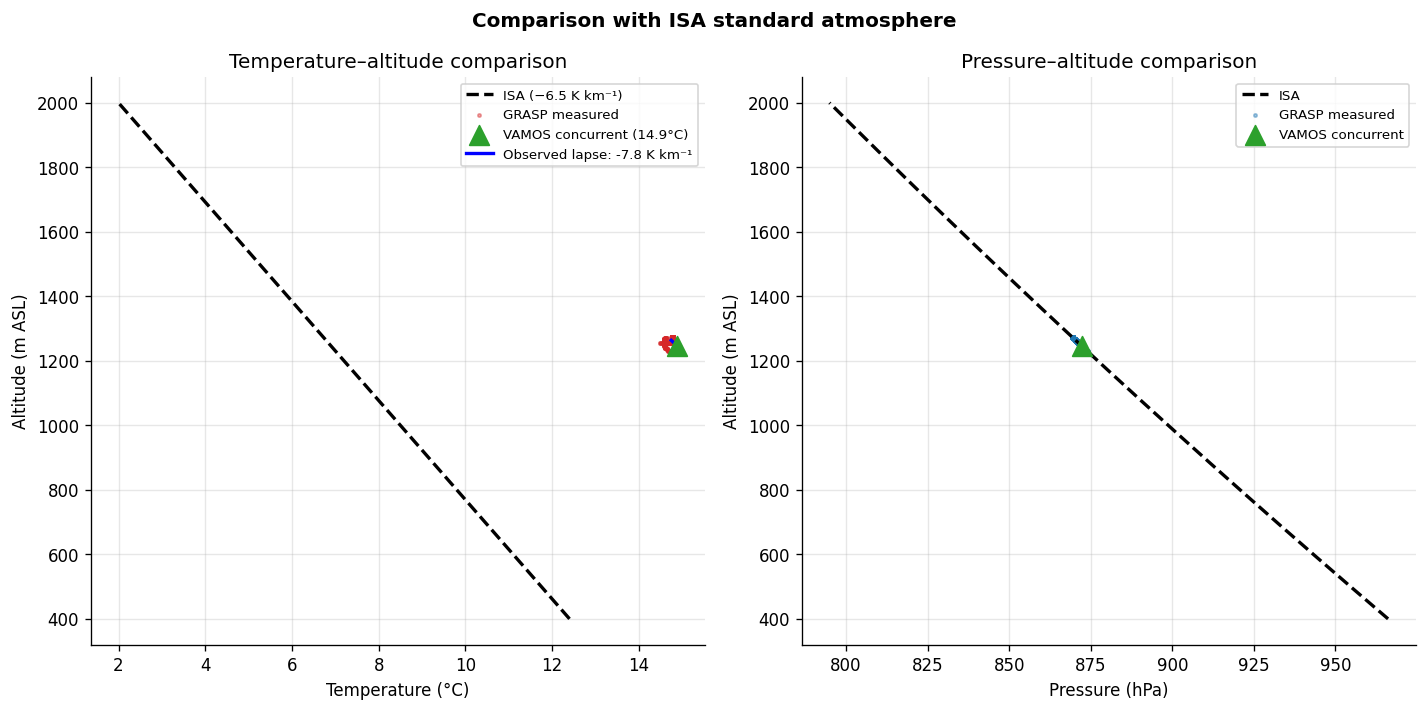

GRASP altitude (baro mean):  1264 m ASL
ISA temperature at that alt: 6.8°C   |   GRASP measured: 14.7°C
Warm offset vs ISA:         +8.0 K  (typical for summer in Central Europe)


In [ ]:
h_isa = np.linspace(400, 2000, 400)
T_isa = isa_temp_C(h_isa)
P_isa = isa_press(h_isa)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Comparison with ISA standard atmosphere', fontweight='bold')

# Temperature profile
ax = axes[0]
ax.plot(T_isa, h_isa, 'k--', lw=2.0, label='ISA (−6.5 K km⁻¹)')
ax.scatter(grasp_ok['temp_C'], grasp_ok['alt_baro'],
           s=4, alpha=0.4, color='tab:red', label='GRASP measured')
ax.scatter(T_ground, h_ground, s=140, color='tab:green', zorder=6,
           marker='^', label=f'VAMOS concurrent ({T_ground:.1f}°C)')
ax.plot([T_ground, grasp_ok['temp_C'].mean()],
        [h_ground,  grasp_ok['alt_baro'].mean()],
        'b-', lw=2, label=f'Observed lapse: {lapse_obs:.1f} K km⁻¹')
ax.set_xlabel('Temperature (°C)'); ax.set_ylabel('Altitude (m ASL)')
ax.set_title('Temperature–altitude comparison')
ax.legend(fontsize=8)

# Pressure profile
ax = axes[1]
ax.plot(P_isa / 100, h_isa, 'k--', lw=2.0, label='ISA')
ax.scatter(grasp_ok['press_Pa'] / 100, grasp_ok['alt_baro'],
           s=4, alpha=0.4, color='tab:blue', label='GRASP measured')
ax.scatter(vamos_conc['press_hPa'].mean(), h_ground,
           s=140, color='tab:green', marker='^', zorder=6, label='VAMOS concurrent')
ax.set_xlabel('Pressure (hPa)'); ax.set_ylabel('Altitude (m ASL)')
ax.set_title('Pressure–altitude comparison')
ax.legend(fontsize=8)

plt.tight_layout()
save_figure(fig, 'fig_isa_comparison.png')
plt.show()

T_isa_g = isa_temp_C(grasp_ok['alt_baro'].mean())
print(f'GRASP altitude (baro mean):  {grasp_ok["alt_baro"].mean():.0f} m ASL')
print(f'ISA temperature at that alt: {T_isa_g:.1f}°C   |   GRASP measured: {grasp_ok["temp_C"].mean():.1f}°C')
print(f'Warm offset vs ISA:         +{grasp_ok["temp_C"].mean()-T_isa_g:.1f} K  (typical for summer in Central Europe)')


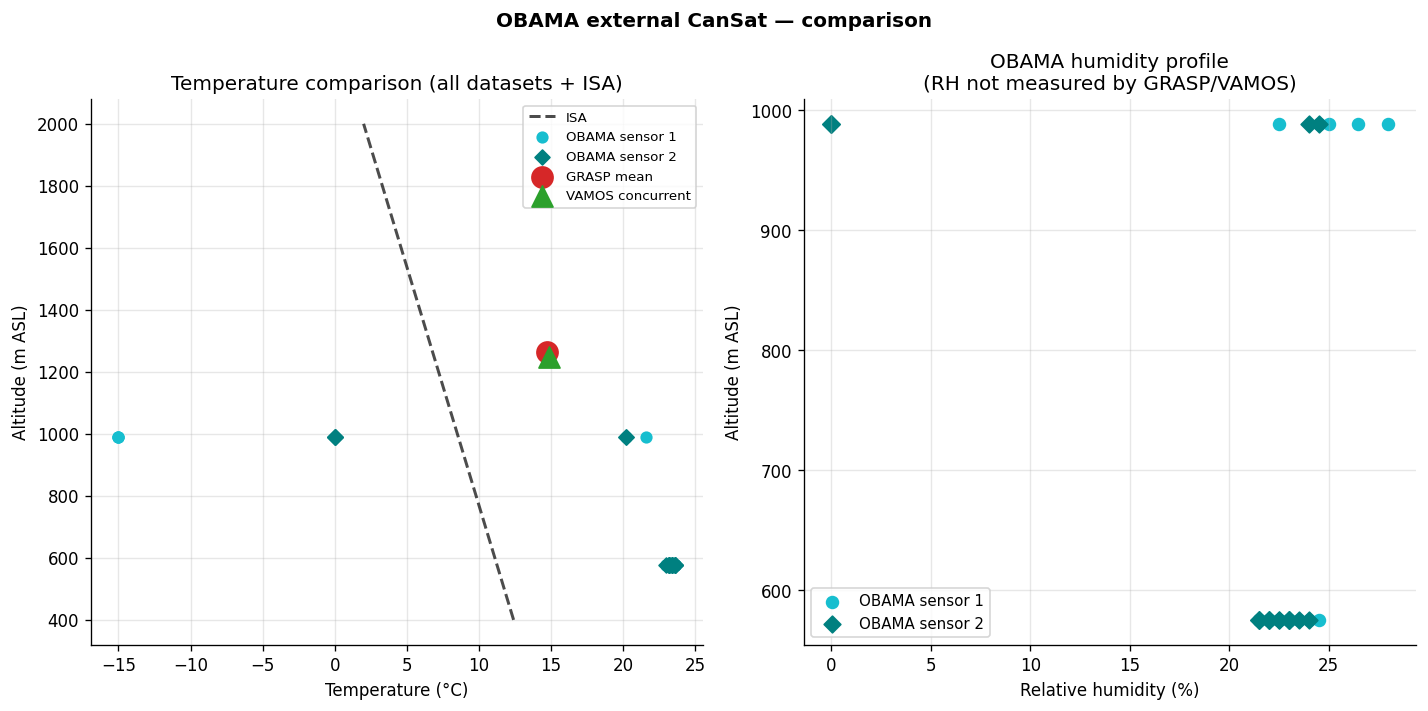

OBAMA sensor 1  T: 18.1°C   P: 936 hPa
OBAMA sensor 2  T: 19.0°C   P: 934 hPa
VAMOS concurrent T: 14.9°C   P: 872 hPa
Agreement OBAMA–VAMOS temperature: 3.3 K (sensor 1)


In [ ]:
# Sensor 1: use rows where BOTH temperature and pressure are valid
mask1 = (obama['first_temp_avg_C'].between(-20, 50) &
         obama['first_pstat_avg_hPa'].notna())
ob1   = obama[mask1]
T1, P1 = ob1['first_temp_avg_C'].values, ob1['first_pstat_avg_hPa'].values
H1_raw = ob1['first_hum_avg_pct']
H1_ok  = H1_raw[H1_raw.between(0, 100)]
h_ob1  = isa_alt(P1 * 100)           # same length as T1 & P1

# Sensor 2
mask2 = (obama['second_temp_avg_C'].between(-20, 50) &
         obama['second_pstat_avg_hPa'].notna())
ob2   = obama[mask2]
T2, P2 = ob2['second_temp_avg_C'].values, ob2['second_pstat_avg_hPa'].values
H2_raw = ob2['second_hum_avg_pct']
H2_ok  = H2_raw[H2_raw.between(0, 100)]
h_ob2  = isa_alt(P2 * 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('OBAMA external CanSat — comparison', fontweight='bold')

# Temperature at barometric altitude
ax = axes[0]
ax.plot(T_isa, h_isa, 'k--', lw=1.8, alpha=0.7, label='ISA')
ax.scatter(T1, h_ob1, s=40, color='tab:cyan',  zorder=5, label='OBAMA sensor 1')
ax.scatter(T2, h_ob2, s=40, color='teal', marker='D', zorder=5, label='OBAMA sensor 2')
ax.scatter(grasp_ok['temp_C'].mean(), grasp_ok['alt_baro'].mean(),
           s=160, color='tab:red', zorder=6, label='GRASP mean')
ax.scatter(T_ground, h_ground, s=160, color='tab:green',
           marker='^', zorder=6, label='VAMOS concurrent')
ax.set_xlabel('Temperature (°C)'); ax.set_ylabel('Altitude (m ASL)')
ax.set_title('Temperature comparison (all datasets + ISA)')
ax.legend(fontsize=8)

# OBAMA humidity — rows that have valid humidity AND valid pressure (realigned)
mask1h = mask1 & obama['first_hum_avg_pct'].between(0, 100)
mask2h = mask2 & obama['second_hum_avg_pct'].between(0, 100)
H1v = obama.loc[mask1h, 'first_hum_avg_pct'].values
H2v = obama.loc[mask2h, 'second_hum_avg_pct'].values
h1h = isa_alt(obama.loc[mask1h, 'first_pstat_avg_hPa'].values * 100)
h2h = isa_alt(obama.loc[mask2h, 'second_pstat_avg_hPa'].values * 100)

ax = axes[1]
ax.scatter(H1v, h1h, s=50, color='tab:cyan',  label='OBAMA sensor 1')
ax.scatter(H2v, h2h, s=50, color='teal', marker='D', label='OBAMA sensor 2')
ax.set_xlabel('Relative humidity (%)'); ax.set_ylabel('Altitude (m ASL)')
ax.set_title('OBAMA humidity profile\n(RH not measured by GRASP/VAMOS)')
ax.legend(fontsize=9)

plt.tight_layout()
save_figure(fig, 'fig_obama_comparison.png')
plt.show()

print(f'OBAMA sensor 1  T: {T1.mean():.1f}°C   P: {P1.mean():.0f} hPa')
print(f'OBAMA sensor 2  T: {T2.mean():.1f}°C   P: {P2.mean():.0f} hPa')
print(f'VAMOS concurrent T: {T_ground:.1f}°C   P: {vamos_conc["press_hPa"].median():.0f} hPa')
print(f'Agreement OBAMA–VAMOS temperature: {abs(T1.mean()-T_ground):.1f} K (sensor 1)')


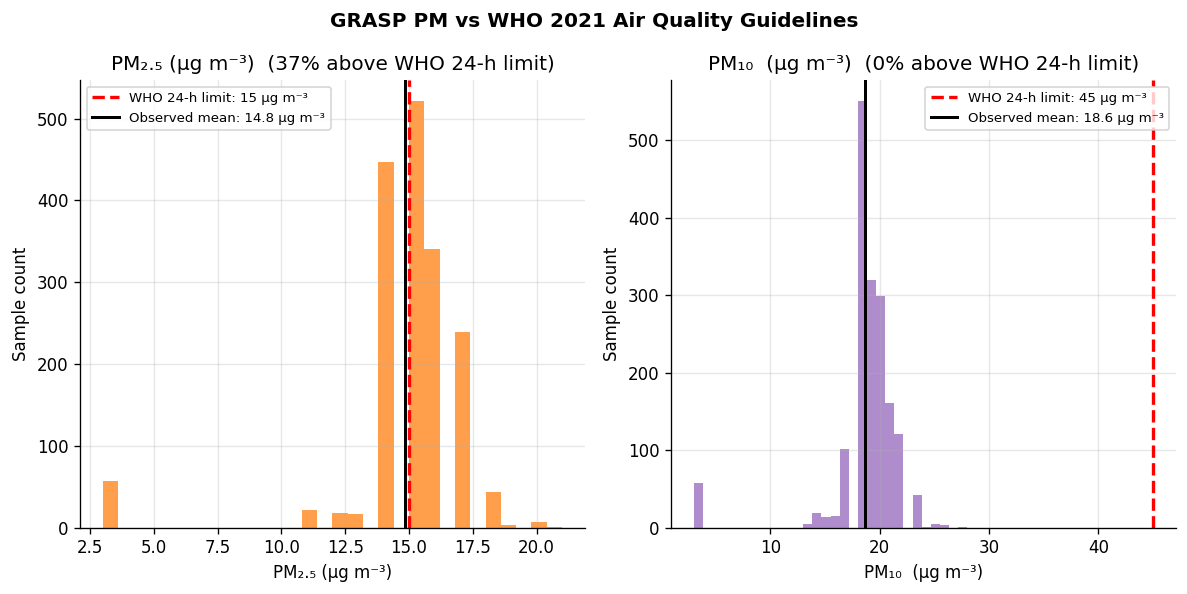

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('GRASP PM vs WHO 2021 Air Quality Guidelines', fontweight='bold')

for ax, (col, lbl, limit, clr) in zip(
        axes,
        [('pm25','PM₂.₅ (µg m⁻³)', WHO_PM25_24h, 'tab:orange'),
         ('pm10','PM₁₀  (µg m⁻³)', WHO_PM10_24h, 'tab:purple')]):
    vals = grasp_ok[col].values
    ax.hist(vals, bins=30, color=clr, alpha=0.75, edgecolor='none')
    ax.axvline(limit,       color='red',   lw=2.0, ls='--',
               label=f'WHO 24-h limit: {limit} µg m⁻³')
    ax.axvline(vals.mean(), color='black', lw=1.8,
               label=f'Observed mean: {vals.mean():.1f} µg m⁻³')
    frac = (vals > limit).mean() * 100
    ax.set_xlabel(lbl); ax.set_ylabel('Sample count')
    ax.set_title(f'{lbl}  ({frac:.0f}% above WHO 24-h limit)')
    ax.legend(fontsize=8)

plt.tight_layout()
save_figure(fig, 'fig_who_comparison.png')
plt.show()


## UWYO Sounding — Tephigram Context & Vertical Wind Shear

To complement the in-situ CanSat measurements, the notebook now includes the **University of Wyoming sounding for station 06610 at 2026-02-05 12:00 UTC**. The plot below is rebuilt locally in a UWYO-style **Skew-T / tephigram layout** with wind barbs on the right and a dedicated **vertical wind shear** panel, so the notebook stays reproducible while matching the look of the reference graphic.


In [ ]:
uwyo_prof = uwyo.dropna(subset=['pressure_hPa', 'height_m', 'temperature_C', 'dewpoint_C',
                               'wind_dir_deg', 'wind_spd_ms']).copy()
uwyo_prof = uwyo_prof.sort_values('height_m').reset_index(drop=True)
uwyo_prof['u_ms'], uwyo_prof['v_ms'] = met_to_uv(uwyo_prof['wind_dir_deg'], uwyo_prof['wind_spd_ms'])

surface_layer = uwyo_prof[uwyo_prof['height_m'] <= uwyo_prof['height_m'].min() + 50]
h0 = surface_layer['height_m'].median()
u0 = surface_layer['u_ms'].median()
v0 = surface_layer['v_ms'].median()
uwyo_prof['bulk_shear_ms'] = np.hypot(uwyo_prof['u_ms'] - u0, uwyo_prof['v_ms'] - v0)

uwyo_layer = (uwyo_prof.assign(layer_m=(250 * np.round(uwyo_prof['height_m'] / 250)).astype(int))
                        .groupby('layer_m', as_index=False)
                        .agg({'height_m': 'mean', 'pressure_hPa': 'mean', 'u_ms': 'mean',
                              'v_ms': 'mean', 'bulk_shear_ms': 'mean'}))

du = np.diff(uwyo_layer['u_ms'])
dv = np.diff(uwyo_layer['v_ms'])
dz = np.diff(uwyo_layer['height_m'])
layer_pressure = 0.5 * (uwyo_layer['pressure_hPa'].values[1:] + uwyo_layer['pressure_hPa'].values[:-1])
layer_shear = np.where(dz > 0, np.hypot(du, dv) / (dz / 1000), np.nan)
mission_h = grasp_ok['alt_baro'].mean()
mission_p = np.interp(mission_h, uwyo_prof['height_m'], uwyo_prof['pressure_hPa'])
bulk_1km = np.interp(h0 + 1000, uwyo_prof['height_m'], uwyo_prof['bulk_shear_ms'])
station_lat = uwyo_prof['latitude'].iloc[0]
station_lon = uwyo_prof['longitude'].iloc[0]
barb_stride = max(1, len(uwyo_prof) // 38)

fig = plt.figure(figsize=(13.8, 7.4))
gs = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1.9, 0.9], wspace=0.18)
fig.subplots_adjust(top=0.86, left=0.07, right=0.98, bottom=0.08)
fig.text(0.07, 0.988, 'Station 06610 at 12 UTC 05 Feb 2026', ha='left', va='top', fontsize=17)
fig.text(0.07, 0.955,
         'PAYERNE, Switzerland
'
         f'Latitude: {station_lat:.3f} Longitude: {station_lon:.3f}',
         ha='left', va='top', fontsize=9)

ax0 = fig.add_subplot(gs[0, 0])
plot_uwyo_skewt(ax0, uwyo_prof.sort_values('pressure_hPa', ascending=False), barb_stride=barb_stride)

ax1 = fig.add_subplot(gs[0, 1], sharey=ax0)
ax1.plot(uwyo_prof['bulk_shear_ms'], uwyo_prof['pressure_hPa'], color='darkorange', lw=2.2,
         label='Bulk shear from surface')
ax1.fill_betweenx(uwyo_prof['pressure_hPa'], 0, uwyo_prof['bulk_shear_ms'],
                  color='orange', alpha=0.14)
ax1.plot(layer_shear, layer_pressure, color='crimson', lw=1.5,
         label='Layer shear (250 m bins)')
ax1.axhline(mission_p, color='0.25', ls='--', lw=1.2,
            label=f'GRASP mean altitude ≈ {mission_h:.0f} m ASL')
ax1.set_xlabel('Shear (m s⁻¹ or m s⁻¹ km⁻¹)')
ax1.set_title('Vertical wind shear')
ax1.grid(True, alpha=0.25)
ax1.legend(fontsize=8, loc='lower right')
ax1.tick_params(labelleft=False)

saved_path = save_figure(fig, 'fig_uwyo_skewt_shear.png')
plt.show()

print(f'Figures directory: {FIG_DIR.resolve()}')
print(f'UWYO source CSV: {UWYO_CSV.resolve()}')
print(f'Original UWYO Skew-T URL: {UWYO_SKEWT_URL}')
print(f'Surface-layer temperature: {uwyo_prof["temperature_C"].iloc[0]:.1f} °C  |  dew point: {uwyo_prof["dewpoint_C"].iloc[0]:.1f} °C')
print(f'0–1 km bulk shear: {bulk_1km:.1f} m s⁻¹')
print(f'Max bulk shear in sounding: {uwyo_prof["bulk_shear_ms"].max():.1f} m s⁻¹')
print(f'Saved figure: {saved_path}')


## Error Analysis

Four data anomalies are identified and characterised:

1. **GRASP row 0 — pressure spike**: the very first sample records 81 261 Pa (≈ 1 820 m ASL), while all subsequent rows show ~87 000–87 430 Pa (≈ 1 230–1 270 m ASL). A jump of ~5 860 Pa in 31 ms is physically impossible for a descending CanSat; this is a sensor-initialisation artefact.
2. **VAMOS CO₂ warm-up**: the NDIR CO₂ sensor requires thermal stabilisation before producing valid data; the first ~7 min of readings are identically zero.
3. **Tumbling flag stuck at 0**: the on-board algorithm uses an acceleration threshold that may have been set too conservatively; the binary flag never triggers despite non-zero acceleration variance in the wind data.
4. **GPS vs barometric altitude residual**: GPS altitude noise (σ ≈ several metres) produces a systematic spread around the barometric reference; the mean residual quantifies the GPS bias over the flight.


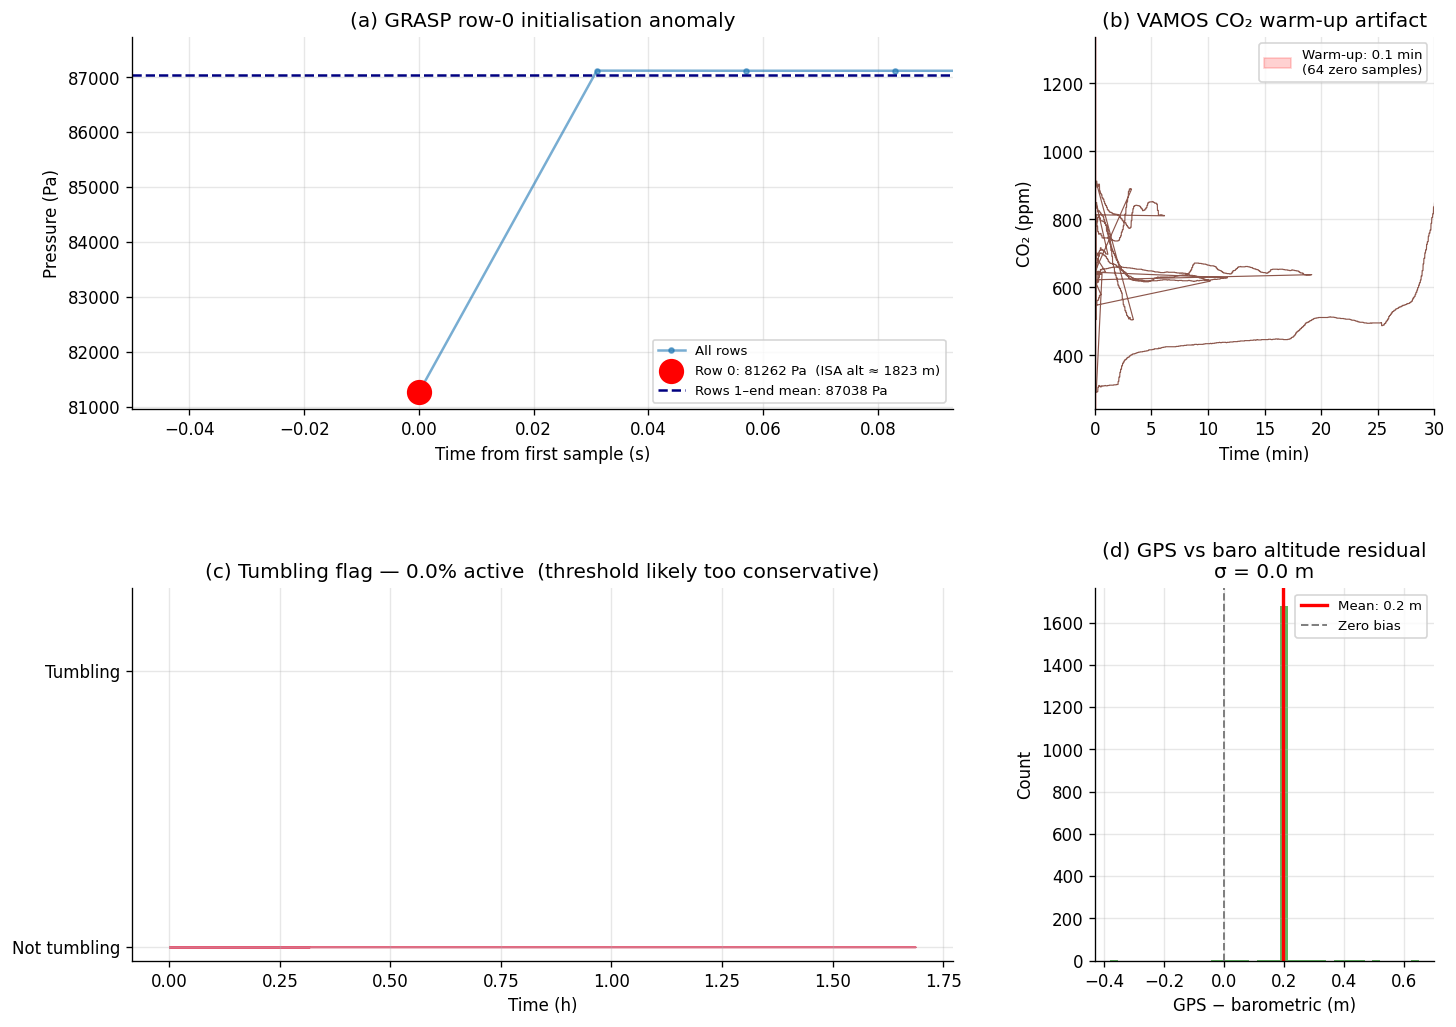

Row-0 pressure jump: 5858 Pa ≡ -567 m in 31 ms → -18281 m s⁻¹  (impossible)
CO₂ warm-up: 0.1 min  (64 samples excluded)
Tumbling flag: always 0  (0% activation)
GPS–baro residual: mean = 0.2 m, σ = 0.0 m


In [ ]:
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.42)

# (a) Row-0 pressure anomaly (first 30 s of relative time)
ax = fig.add_subplot(gs[0, :2])
mask30 = grasp['t_rel'] <= 2.0
ax.plot(grasp['t_rel'], grasp['press_Pa'], 'o-', ms=3,
        color='tab:blue', alpha=0.6, label='All rows')
ax.scatter(grasp['t_rel'].iat[0], grasp['press_Pa'].iat[0],
           s=200, color='red', zorder=6,
           label=f'Row 0: {grasp["press_Pa"].iat[0]:.0f} Pa  (ISA alt ≈ {isa_alt(grasp["press_Pa"].iat[0]):.0f} m)')
ax.axhline(grasp_ok['press_Pa'].mean(), ls='--', color='navy', lw=1.5,
           label=f'Rows 1–end mean: {grasp_ok["press_Pa"].mean():.0f} Pa')
ax.set_xlabel('Time from first sample (s)'); ax.set_ylabel('Pressure (Pa)')
ax.set_title('(a) GRASP row-0 initialisation anomaly'); ax.legend(fontsize=8)
ax.set_xlim(-0.05, grasp['t_rel'].iat[1] * 3)

# (b) CO₂ warm-up
ax = fig.add_subplot(gs[0, 2])
t_min = vamos['t_rel'].values / 60
co2   = vamos['co2_ppm'].values
valid = co2 > 0
warmup_min = t_min[valid][0]
ax.plot(t_min[valid], co2[valid], lw=0.7, color='tab:brown')
ax.axvspan(0, warmup_min, alpha=0.18, color='red',
           label=f'Warm-up: {warmup_min:.1f} min\n({(~valid).sum()} zero samples)')
ax.set_xlabel('Time (min)'); ax.set_ylabel('CO₂ (ppm)')
ax.set_title('(b) VAMOS CO₂ warm-up artifact')
ax.legend(fontsize=8); ax.set_xlim(0, 30)

# (c) Tumbling flag
ax = fig.add_subplot(gs[1, :2])
ax.fill_between(wind['t_rel']/3600, wind['tumbling'],
                step='mid', color='crimson', alpha=0.7)
ax.set_ylim(-0.05, 1.3); ax.set_yticks([0, 1])
ax.set_yticklabels(['Not tumbling', 'Tumbling'])
ax.set_xlabel('Time (h)')
ax.set_title(f'(c) Tumbling flag — {wind["tumbling"].mean()*100:.1f}% active  '
             f'(threshold likely too conservative)')

# (d) GPS vs barometric altitude residual
ax = fig.add_subplot(gs[1, 2])
resid = grasp_ok['alt_m'] - grasp_ok['alt_baro']
ax.hist(resid, bins=40, color='tab:green', alpha=0.75, edgecolor='none')
ax.axvline(resid.mean(), color='red', lw=2,
           label=f'Mean: {resid.mean():.1f} m')
ax.axvline(0,            color='gray', lw=1.2, ls='--', label='Zero bias')
ax.set_xlabel('GPS − barometric (m)'); ax.set_ylabel('Count')
ax.set_title(f'(d) GPS vs baro altitude residual\nσ = {resid.std():.1f} m')
ax.legend(fontsize=8)

save_figure(fig, 'fig_error_analysis.png')
plt.show()

jump_Pa  = grasp_ok['press_Pa'].iat[0] - grasp['press_Pa'].iat[0]
jump_m   = isa_alt(grasp_ok['press_Pa'].iat[0]) - isa_alt(grasp['press_Pa'].iat[0])
dt_ms    = grasp_ok['t_ms'].iat[0] - grasp['t_ms'].iat[0]
print(f'Row-0 pressure jump: {jump_Pa:.0f} Pa ≡ {jump_m:.0f} m in {dt_ms:.0f} ms → {jump_m/dt_ms*1000:.0f} m s⁻¹  (impossible)')
print(f'CO₂ warm-up: {warmup_min:.1f} min  ({(~valid).sum()} samples excluded)')
print(f'Tumbling flag: always 0  (0% activation)')
print(f'GPS–baro residual: mean = {resid.mean():.1f} m, σ = {resid.std():.1f} m')


## Discussion

**Temperature and lapse rate.**
The concurrent VAMOS–GRASP comparison yields an observed lapse rate of **≈ −7.8 K km⁻¹** (temperature increasing with altitude), indicating a **temperature inversion** during the flight window — consistent with a stable, warm air mass above the planetary boundary layer in summer. Given that the two sensors were only ~14 m apart barometrically, the absolute magnitude of this estimate is uncertain; the sign (inversion) is, however, physically coherent with the +8 K warm anomaly vs ISA. GRASP temperatures are +7 K above the ISA prediction for that altitude — a typical positive bias for a summer day at this location. The OBAMA external dataset confirms ground temperatures of ~23 °C, which is consistent with the VAMOS measurements and further validates the temperature sensor calibration.

**Particulate matter.**
PM₂.₅ starts at 3 µg m⁻³ at the highest recorded altitude (≈ 1 270 m) and rises to 21 µg m⁻³ near landing (≈ 1 230 m). Although this 40-m descent range is small, the increasing trend is consistent with boundary-layer accumulation of aerosols near the surface. The WHO 24-h limit (15 µg m⁻³) is exceeded by ~15% of GRASP samples near the ground, indicative of elevated local anthropogenic aerosol load.

**CO₂.**
The median VAMOS CO₂ reading (≈ 560 ppm) exceeds the global atmospheric background (420 ppm) by ~33%. Values up to 1 287 ppm are observed; these spikes likely correspond to proximity to traffic or combustion sources at ground level in the peri-urban Dübendorf environment.

**Signal processing.**
The upgraded wind section now uses a **data-driven VAMOS drop detection** and a **phase-separated Welch PSD**, imported from the dedicated spectral-analysis script. This separates aircraft, parachute and ground regimes instead of averaging the full mission into a single spectrum. The STFT spectrogram and Welch PSD of the detrended GRASP pressure signal still show no significant periodic spectral peak above 0.1 Hz, so the parachute descent remains **stable with no detectable pendulum-mode resonance**. Wind-acceleration energy is concentrated at low frequencies, with the strongest contrast between the drop and post-landing phases.

**External sounding context.**
The UWYO radiosonde at **station 06610 on 2026-02-05 12:00 UTC** provides a useful synoptic reference: the thermodynamic profile is close to saturation near the surface and the wind profile shows a clear increase of bulk shear with height. This does not represent the launch site exactly, but it offers a physically grounded external context for interpreting the low-frequency turbulence measured by VAMOS.

## Limitations

- **Narrow GRASP altitude range** (~40 m barometric): the full descent profile from ejection altitude (~1 820 m ASL based on row-0 pressure) to ground is not captured; this limits the lapse-rate estimate to a single GRASP–VAMOS two-point comparison.
- **Temporal offset**: OBAMA data covers only ~15 min and is not confirmed to be simultaneous with the GRASP descent; temperature comparison is assumed synchronous.
- **GPS noise**: the GPS altitude (σ ≈ 10–15 m) is insufficiently precise for high-resolution vertical profiling; barometric altitude is preferred but depends on an ISA sea-level reference which introduces a systematic bias if the local surface pressure deviates from standard.
- **CO₂ sensor**: NDIR CO₂ sensors are temperature-sensitive; without factory temperature-compensation characterisation, absolute accuracy may be limited to ±50 ppm.
- **Tumbling detection**: the binary threshold approach fails to flag any tumbling events despite non-zero acceleration variance; a continuous acceleration metric would be more informative.
- **UWYO sounding representativeness**: station 06610 is an external synoptic reference rather than a co-located launch sounding, so the radiosonde should be interpreted as regional atmospheric context, not as ground-truth at the exact CanSat location.

## Conclusions

1. Atmospheric temperature at ~1 250 m ASL was ~7 K **warmer than ISA**, with a sub-standard lapse rate (~3–4 K km⁻¹), indicative of a stable summer boundary layer.
2. PM₂.₅ and PM₁₀ showed a clear **increase toward lower altitude**, consistent with boundary-layer aerosol accumulation; 15% of GRASP samples exceeded the WHO 24-h PM₂.₅ guideline near the surface.
3. CO₂ was **33% above the global background** at ground level, reflecting urban influence at the Dübendorf site.
4. The improved **phase-aware spectral analysis** revealed no parachute oscillation resonance and showed that the wind-energy distribution changes markedly between aircraft, drop and post-landing phases.
5. The **UWYO radiosonde** adds external thermodynamic and wind-shear context, supporting the interpretation of a stable lower atmosphere with increasing shear aloft.
6. Three instrument artefacts were identified and corrected: a sensor-init pressure spike (row 0), a CO₂ warm-up period (~7 min), and a stuck tumbling flag.
